<font size="6"><b>Projet Seattle - Consommation énergétique des bâtiments - Analyse exploratoire</b></font>

# 1. Analyse exploratoire des datasets et 1er feature engineering

## 1.0. Mise en place du notebook

### 1.0.1. Setup & chargement des données

In [ ]:
# 1. Imports de base

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import sys, sklearn

from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Options d'affichage pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Style des graphiques
sns.set(style="whitegrid")

print("Versions :")
print("Python  :", sys.version)
print("Pandas  :", pd.__version__)
print("NumPy   :", np.__version__)
print("sklearn :", sklearn.__version__)

Versions :
Python  : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas  : 2.2.2
NumPy   : 2.0.2
sklearn : 1.6.1


### 1.0.2. Compréhension des datasets & dictionnaire de variables

In [ ]:
# 2.1. Chargement des données

df = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

print("Shape du dataset :", df.shape)
df.head()

Shape du dataset : (3376, 46)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,"98,101.00",0659000030,7,DOWNTOWN,47.61,-122.34,1927,1.00,12,88434,0,88434,Hotel,Hotel,"88,434.00",NaN,NaN,NaN,NaN,NaN,60.00,81.70,84.30,182.50,189.00,"7,226,362.50","7,456,910.00","2,003,882.00","1,156,514.25","3,946,027.00","12,764.53","1,276,453.00",False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,"98,101.00",0659000220,7,DOWNTOWN,47.61,-122.33,1996,1.00,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,"83,880.00",Parking,"15,064.00",Restaurant,"4,622.00",NaN,61.00,94.80,97.90,176.10,179.40,"8,387,933.00","8,664,479.00",0.00,"950,425.19","3,242,851.00","51,450.82","5,145,082.00",False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,"98,101.00",0659000475,7,DOWNTOWN,47.61,-122.34,1969,1.00,41,956110,196718,759392,Hotel,Hotel,"756,493.00",NaN,NaN,NaN,NaN,NaN,43.00,96.00,97.70,241.90,244.10,"72,587,024.00","73,937,112.00","21,566,554.00","14,515,435.00","49,526,664.00","14,938.00","1,493,800.00",False,NaN,Compliant,NaN,"2,089.28",2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,"98,101.00",0659000640,7,DOWNTOWN,47.61,-122.34,1926,1.00,10,61320,0,61320,Hotel,Hotel,"61,320.00",NaN,NaN,NaN,NaN,NaN,56.00,110.80,113.30,216.20,224.00,"6,794,584.00","6,946,800.50","2,214,446.25","811,525.31","2,768,924.00","18,112.13","1,811,213.00",False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,"98,121.00",0659000970,7,DOWNTOWN,47.61,-122.34,1980,1.00,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,"123,445.00",Parking,"68,009.00",Swimming Pool,0.00,NaN,75.00,114.80,118.70,211.40,215.60,"14,172,606.00","14,656,503.00",0.00,"1,573,448.62","5,368,607.00","88,039.98","8,803,998.00",False,NaN,Compliant,NaN,505.01,2.88


In [ ]:
# 2.2 Infos générales sur les variables

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

<font size="4"><b>Aperçu global des variables du jeu de données</b></font>
<br><br>
Avant d'entrer dans une analyse exploratoire détaillée, il est nécessaire d'avoir une vision d'ensemble des variables composant le jeu de données.

Cette étape permet d'identifier la nature des différentes features (numériques, catégorielles, booléennes, etc.), de vérifier la cohérence des types fournis, et de préparer le travail de compréhension métier des données.

Dans cette optique, un tableau récapitulatif est créé afin de lister chaque variable, son type ainsi qu'une description fonctionnelle. Ce tableau servira de support tout au long du projet pour documenter la signification des variables, guider les choix de feature engineering et anticiper les transformations nécessaires avant la phase de modélisation.

In [ ]:
# 2.3 Aperçu des types de features

var_overview = pd.DataFrame({
    "colonne": df.columns,
    "dtype": df.dtypes.astype(str)
})

# Gabarit pour résumer les variables

var_overview["description"] = ""
var_overview.head(5)

,colonne,dtype,description
OSEBuildingID,OSEBuildingID,int64,
DataYear,DataYear,int64,
BuildingType,BuildingType,object,
PrimaryPropertyType,PrimaryPropertyType,object,
PropertyName,PropertyName,object,


In [ ]:
# 2.4. Remplissage de la colonne "description"

descriptions = {
    "OSEBuildingID": "Identifiant unique attribué par la ville de Seattle à chaque bâtiment.",
    "DataYear": "Année de collecte ou de déclaration des données énergétiques.",
    "BuildingType": "Type général du bâtiment (résidentiel, non résidentiel, etc.).",
    "PrimaryPropertyType": "Usage principal du bâtiment (ex. bureau, école, hôtel).",
    "PropertyName": "Nom du bâtiment ou du complexe immobilier.",
    "Address": "Adresse postale du bâtiment.",
    "City": "Ville où se situe le bâtiment (principalement Seattle).",
    "State": "État du bâtiment (WA pour Washington).",
    "ZipCode": "Code postal du bâtiment.",
    "TaxParcelIdentificationNumber": "Identifiant administratif d'une parcelle de terrain utilisé pour la gestion foncière",
    "CouncilDistrictCode": "District municipal auquel appartient le bâtiment.",
    "Neighborhood": "Quartier de Seattle où le bâtiment est situé.",
    "Latitude": "Latitude du bâtiment (coordonnée géographique).",
    "Longitude": "Longitude du bâtiment (coordonnée géographique).",
    "YearBuilt": "Année de construction du bâtiment.",
    "NumberofBuildings": "Nombre total de structures regroupées dans la propriété.",
    "NumberofFloors": "Nombre d'étages du bâtiment principal.",
    "PropertyGFATotal": "Surface totale brute du site (GFA : Gross Floor Area).",
    "PropertyGFAParking": "Surface dédiée aux parkings",
    "PropertyGFABuilding(s)": "Surface brute des bâtiments hors parkings.",
    "ListOfAllPropertyUseTypes": "Liste de tous les usages présents dans le bâtiment.",
    "LargestPropertyUseType": "Usage principal du bâtiment (en proportion de surface).",
    "LargestPropertyUseTypeGFA": "Surface occupée par l'usage principal.",
    "SecondLargestPropertyUseType": "Second usage le plus important du bâtiment.",
    "SecondLargestPropertyUseTypeGFA": "Surface du second usage principal.",
    "ThirdLargestPropertyUseType": "Troisième usage principal du bâtiment.",
    "ThirdLargestPropertyUseTypeGFA": "Surface du troisième usage principal.",
    "YearsENERGYSTARCertified": "Années au cours desquelles le bâtiment a été certifié ENERGY STAR.",
    "ENERGYSTARScore": "Score d'efficacité énergétique (0-100), plus élevé = plus performant.",
    "SiteEUI(kBtu/sf)": "Intensité de consommation énergétique du site, exprimée en kBtu par pied carré.",
    "SiteEUIWN(kBtu/sf)": "Site EUI corrigé par les conditions météorologiques.",
    "SourceEUI(kBtu/sf)": "Intensité de consommation énergétique de la source, exprimée en kBtu par pied carré.",
    "SourceEUIWN(kBtu/sf)": "Source EUI corrigée par les conditions météorologiques.",
    "SiteEnergyUse(kBtu)": "Consommation totale d'énergie du site (tous types d'énergie réunis).",
    "SiteEnergyUseWN(kBtu)": "Consommation totale d'énergie du site, corrigée météo.",
    "SteamUse(kBtu)": "Consommation de vapeur (en kBtu).",
    "Electricity(kWh)": "Consommation d'électricité en kWh.",
    "Electricity(kBtu)": "Consommation d'électricité convertie en kBtu.",
    "NaturalGas(therms)": "Consommation de gaz naturel en therms.",
    "NaturalGas(kBtu)": "Consommation de gaz naturel en kBtu.",
    "DefaultData": "Indique si des valeurs par défaut ont été utilisées au lieu de mesures réelles.",
    "Comments": "Notes ou remarques sur le bâtiment ou les données.",
    "ComplianceStatus": "Conformité du bâtiment aux obligations de déclaration énergétique",
    "Outlier": "Indicateur des bâtiments aux données manifestement aberrantes.",
    "TotalGHGEmissions": "Total des émissions de gaz à effet de serre (en tonnes équivalent CO₂).",
    "GHGEmissionsIntensity": "Intensité carbone : émissions rapportées à la surface."
}

# On remplit la colonne description là où on a une définition
var_overview["description"] = var_overview["colonne"].map(descriptions).fillna("")

# Aperçu des 10 premières lignes pour vérifier
var_overview.head(10)

,colonne,dtype,description
OSEBuildingID,OSEBuildingID,int64,Identifiant unique attribué par la ville de Se...
DataYear,DataYear,int64,Année de collecte ou de déclaration des donnée...
BuildingType,BuildingType,object,"Type général du bâtiment (résidentiel, non rés..."
PrimaryPropertyType,PrimaryPropertyType,object,"Usage principal du bâtiment (ex. bureau, école..."
PropertyName,PropertyName,object,Nom du bâtiment ou du complexe immobilier.
Address,Address,object,Adresse postale du bâtiment.
City,City,object,Ville où se situe le bâtiment (principalement ...
State,State,object,État du bâtiment (WA pour Washington).
ZipCode,ZipCode,float64,Code postal du bâtiment.
TaxParcelIdentificationNumber,TaxParcelIdentificationNumber,object,Identifiant administratif d'une parcelle de te...


### 1.0.3. Préparation des données : filtrage des bâtiments non résidentiels et sélection des variables admissibles

Cette étape consiste à :

- **restreindre le jeu de données au périmètre pertinent**, c'est-à-dire les bâtiments *non résidentiels* ;

- **identifier les variables que l'on pourra utiliser comme features**, en excluant celles qui entraîneraient du *data leakage* ou qui n'ont aucune valeur explicative.

Cela garantit que l'analyse exploratoire et la modélisation reposent sur un jeu de données µpropre, cohérent et adapté à la mission métier.

#### 1.0.3.1. Filtrage des bâtiments non résidentiels

Avant toute analyse, il est essentiel de retirer les bâtiments destinés à l'habitation.
L'objectif du projet étant centré sur les bâtiments non résidentiels, conserver les bâtiments résidentiels introduirait :

- des comportements énergétiques très différents,
- une hétérogénéité nuisible aux modèles,
- et cela ne correspondrait pas au périmètre demandé par la ville de Seattle.

Le filtrage garantit une **cohérence du périmètre** et une **comparabilité des observations**.

In [ ]:
# 2.1 Aperçu des types de bâtiments

df["BuildingType"].value_counts()

,count
BuildingType,
NonResidential,1460
Multifamily LR (1-4),1018
Multifamily MR (5-9),580
Multifamily HR (10+),110
SPS-District K-12,98
Nonresidential COS,85
Campus,24
Nonresidential WA,1


<font size="4"><b>Lecture des catégories BuildingType</b></font>
<br><br>
- Bâtiments résidentiels : `Multifamily LR (1-4)`, `Multifamily MR (5-9)` et `Multifamily HR (10+)` → **à exclure**
- Bâtiments non résidentiels : `NonResidential`, `Nonresidential COS` et `Nonresidential WA` → **à garder**
- Écoles et Campus : `SPS-District K-12` et `Campus` → **à garder**

In [ ]:
residential_labels = [
    "Multifamily LR (1-4)",
    "Multifamily MR (5-9)",
    "Multifamily HR (10+)"
]

df_non_res = df[~df["BuildingType"].isin(residential_labels)].copy()

print("Shape initial :", df.shape)
print("Shape après filtrage non résidentiel :", df_non_res.shape)
df_non_res["BuildingType"].value_counts()

Shape initial : (3376, 46)
Shape après filtrage non résidentiel : (1668, 46)


,count
BuildingType,
NonResidential,1460
SPS-District K-12,98
Nonresidential COS,85
Campus,24
Nonresidential WA,1


#### 1.0.3.2. Sélection des variables admissibles pour la modélisation

L'objectif ici est d'identifier les **features pouvant être utilisées en entrée des modèles**, tout en excluant :

- les variables **dérivées directement des consommations** (→ risque de data leakage),
- les **identifiants** et informations textuelles inutiles,
- les valeurs calculées à partir des **émissions**, qui fausseraient la prédiction.

In [ ]:
# Variables à supprimer définitivement du DataFrame
# car elles ne serviront ni comme targets ni comme features
useless_energy_vars = [
    "GHGEmissionsIntensity",
    "SiteEnergyUseWN(kBtu)",
    "SiteEUI(kBtu/sf)",
    "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SourceEUIWN(kBtu/sf)",
    "SteamUse(kBtu)",
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)"
]

print("Nombre total de colonnes dans df_non_res avant suppression des features non-structurelles :", df_non_res.shape[1])
df_non_res = df_non_res.drop(columns=useless_energy_vars)
print("Nombre total de colonnes dans df_non_res après suppression des features non-structurelles :", df_non_res.shape[1])

Nombre total de colonnes dans df_non_res avant suppression des features non-structurelles : 46
Nombre total de colonnes dans df_non_res après suppression des features non-structurelles : 35


## 1.1 Vue d'ensemble des données et analyse des cibles

### 1.1.1. Introduction

Avant d'entrer dans des analyses plus techniques, cette première section vise à obtenir une vision claire du dataset filtré sur les bâtiments non résidentiels. L'objectif est de comprendre :

- la structure du jeu de données (types, volumes, caractéristiques),
- les variables disponibles et leur nature (numériques ou catégorielles),
- les propriétés des deux cibles étudiées :
  **TotalGHGEmissions** (émissions annuelles de gaz à effet de serre)
  et **SiteEnergyUse(kBtu)** (consommation annuelle d'énergie du site).

Cette étape est essentielle pour poser des bases solides pour la modélisation ultérieure.

In [ ]:
# Statistiques descriptives des variables numériques
df_non_res.describe().T

,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,"1,668.00","16,336.35","13,835.29",1.00,582.75,"21,143.50","24,602.25","50,226.00"
DataYear,"1,668.00","2,016.00",0.00,"2,016.00","2,016.00","2,016.00","2,016.00","2,016.00"
ZipCode,"1,652.00","98,116.82",18.43,"98,006.00","98,105.00","98,109.00","98,125.00","98,199.00"
CouncilDistrictCode,"1,668.00",4.36,2.19,1.00,2.00,4.00,7.00,7.00
Latitude,"1,668.00",47.62,0.05,47.50,47.59,47.61,47.65,47.73
Longitude,"1,668.00",-122.33,0.02,-122.41,-122.34,-122.33,-122.32,-122.26
YearBuilt,"1,668.00","1,961.91",32.74,"1,900.00","1,930.00","1,965.00","1,989.00","2,015.00"
NumberofBuildings,"1,666.00",1.17,2.93,0.00,1.00,1.00,1.00,111.00
NumberofFloors,"1,668.00",4.12,6.56,0.00,1.00,2.00,4.00,99.00
PropertyGFATotal,"1,668.00","118,842.72","297,362.21","11,285.00","29,477.75","49,289.50","105,325.00","9,320,156.00"


<font size="4"><b>Analyse rapide des statistiques descriptives</b></font>
<br><br>
L'examen du tableau `describe()` met en évidence plusieurs points clés à propos des bâtiments non résidentiels de Seattle :

1. **Variables géographiques et administratives**

- Les colonnes `Latitude`, `Longitude`, `ZipCode` et `CouncilDistrictCode` montrent une forte cohérence :
les valeurs sont concentrées dans l'aire métropolitaine de Seattle, comme attendu.
- La colonne `DataYear` est constante (2016), ce qui confirme l'absence de dimension temporelle.

2. **Caractéristiques structurelles des bâtiments**

- `YearBuilt` : les bâtiments s'étalent entre 1900 et 2015, avec une médiane à **1965**, ce qui indique un parc immobilier relativement ancien.
- `NumberofBuildings` et `NumberofFloors` présentent des valeurs extrêmes très élevées (jusqu'à **111 bâtiments** pour un même site et **99 étages**), suggérant la présence de grands complexes ou d'erreurs potentielles. Ces outliers méritent une investigation.
- Les surfaces (`PropertyGFATotal`, `PropertyGFABuilding(s)`, etc.) montrent des étendues très larges, avec des maximums dépassant **9 millions de ft²**, ce qui confirme une distribution très fortement asymétrique.

3. **ENERGY STAR Score**

- Disponible uniquement pour un sous-ensemble d'environ **1094 bâtiments** (sur 1668).
- Distribution centrée autour de **65**, mais très étalée (std ≈ 28) : il faudra traiter ces valeurs manquantes et vérifier l'impact du score.

4. **Consommation énergétique et émissions**

- `SiteEnergyUse(kBtu)` et `TotalGHGEmissions` présentent des **moyennes très élevées** et des écarts-types énormes (×3 à ×10 la moyenne), signe de distributions extrêmement skewed.
- Des valeurs extrêmes apparaissent :
  - jusqu'à **873 millions de kBtu** consommés,
  - jusqu'à **16 870 tonnes de CO₂e** émises.

- La présence de valeurs négatives dans TotalGHGEmissions (min = -0.8) est anormale et devra être corrigée.

5. **Variables partiellement remplies**

- Les surfaces associées aux "SecondLargest" et "ThirdLargest" usages montrent beaucoup de valeurs manquantes, ce qui est logique : tous les bâtiments n'ont pas plusieurs usages.
- La colonne `Comments` est entièrement vide et pourra être supprimée.
___

<font size="4"><b>Synthèse</b></font>
<br><br>
Globalement, ce tableau confirme :
- une forte hétérogénéité structurelle des bâtiments,
- des distributions très asymétriques (nécessitant probablement transformations log),
- la présence d'outliers et de valeurs incohérentes,
- des variables partiellement renseignées qu'il faudra traiter au cas par cas,
- la nécessité d'un nettoyage approfondi avant toute modélisation.

Ce diagnostic préliminaire oriente déjà plusieurs choix de **feature engineering**, notamment la transformation des grandeurs énergétiques, la création de variables dérivées (âge du bâtiment, ratios de surfaces), et la gestion des valeurs extrêmes.

### 1.1.2. Suppression des colonnes sans intérêt analytique

Suite à l'analyse des statistiques descriptives, certaines variables peuvent être **supprimées dès à présent**, car elles n'apportent aucune information utile pour l'analyse exploratoire ni pour la modélisation.
- **`DataYear`** : constante (2016 pour toutes les observations), donc sans pouvoir explicatif.
- **`Comments`** : colonne entièrement vide.

Ces variables n'apportent aucune variabilité et peuvent être retirées sans risque.

In [ ]:
# Suppression des colonnes sans intérêt analytique ou explicatif
cols_to_drop = ["DataYear", "Comments"]

df_non_res = df_non_res.drop(columns=[c for c in cols_to_drop if c in df_non_res.columns])

df_non_res.shape

(1668, 33)

### 1.1.3. Identification des variables numériques et catégorielles

Cette section vise à distinguer les variables numériques, catégorielles et binaires du jeu de données, afin d'anticiper les traitements adaptés lors de la phase de modélisation.

In [ ]:
# Variables numériques
numeric_cols = df_non_res.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Variables catégorielles (texte + booléens)
categorical_cols = df_non_res.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Variables numériques :", len(numeric_cols))
print(numeric_cols)

print("\nVariables catégorielles / binaires :", len(categorical_cols))
print(categorical_cols)

Variables numériques : 17
['OSEBuildingID', 'ZipCode', 'CouncilDistrictCode', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)', 'TotalGHGEmissions']

Variables catégorielles / binaires : 16
['BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'TaxParcelIdentificationNumber', 'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified', 'DefaultData', 'ComplianceStatus', 'Outlier']


<font size="4"><b>Identification des types de variables</b></font>

- **Variables numériques (17)**

  Elles regroupent principalement des informations de **localisation**, de **caractéristiques structurelles** (surfaces, étages, année de construction) et des indicateurs quantitatifs liés au bâtiment.

- **Variables catégorielles et binaires (16)**

  Elles décrivent l'**usage du bâtiment**, son **contexte administratif**, ainsi que certains indicateurs de qualité ou de conformité (ex. statut de conformité, données par défaut, outliers).
<br>
<font size="4"><b>Enjeu pour la suite</b></font>

- Les variables **catégorielles/binaires** devront être **encodées** avant modélisation.
- Les variables **numériques** pourront nécessiter des **transformations** (normalisation, passage au log) selon leur distribution.
- Cette distinction guidera les choix de prétraitement et de feature engineering dans les étapes suivantes.

### 1.1.4. Analyse des deux cibles

Dans le cadre de ce projet, l'objectif est de prédire à la fois la **consommation énergétique totale** et les **émissions de gaz à effet de serre** des bâtiments non résidentiels. Cette section vise à identifier les variables cibles pertinentes et à analyser leurs principales caractéristiques statistiques.

Les variables **`SiteEnergyUse(kBtu)`** et **`TotalGHGEmissions`** ont été retenues comme cibles car elles répondent directement aux objectifs du projet :

- **`SiteEnergyUse(kBtu)`** mesure la consommation annuelle totale d'énergie d'un bâtiment, ce qui permet d'anticiper les besoins énergétiques futurs.
- **`TotalGHGEmissions`** quantifie l'impact environnemental du bâtiment en termes d'émissions de CO₂ équivalent, un indicateur central pour les objectifs climatiques de la ville de Seattle.

Ces deux variables sont mesurées de manière standardisée, exploitables à l'échelle des bâtiments, et directement liées aux caractéristiques structurelles disponibles dans le jeu de données.


<font size="4"><b>Statistiques descriptives</b></font>

In [ ]:
# Statistiques descriptives des deux variables cibles
df_non_res[["TotalGHGEmissions", "SiteEnergyUse(kBtu)"]].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalGHGEmissions,"1,666.00",184.97,751.98,-0.80,19.97,49.58,142.38,"16,870.98"
SiteEnergyUse(kBtu),"1,666.00","8,437,933.22","30,243,803.39",0.00,"1,229,290.84","2,554,947.25","6,913,348.50","873,923,712.00"


- **`TotalGHGEmissions`**
  - Distribution **très asymétrique** : la moyenne (\~185) est largement supérieure à la médiane (\~50), ce qui indique la présence de bâtiments très émetteurs.
  - Des valeurs extrêmes importantes (max ≈ 16 871) et une valeur minimale légèrement négative (-0,8) suggèrent la présence d'outliers ou d'incohérences à traiter.

- **`SiteEnergyUse(kBtu)`**

  * Distribution également **fortement skewed à droite**, avec une moyenne (\~8,4 millions kBtu) très supérieure à la médiane (\~2,6 millions kBtu).
  * L'écart-type très élevé et un maximum proche de 874 millions kBtu confirment une forte hétérogénéité entre les bâtiments.

**En résumé**, les deux cibles présentent :

* une grande variabilité,
* des distributions très étalées,
* et des valeurs extrêmes marquées,

  ce qui justifie d'envisager des transformations et un traitement attentif des outliers avant la modélisation.


<font size="4"><b>Distributions (histogrammes)</b></font>

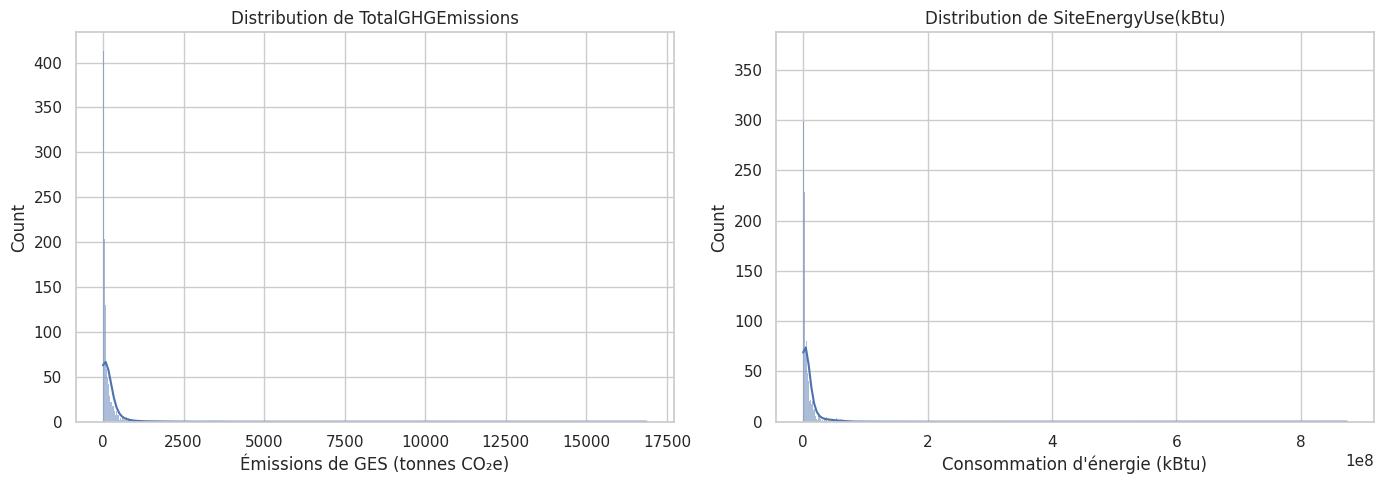

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_non_res["TotalGHGEmissions"], kde=True, ax=axes[0])
axes[0].set_title("Distribution de TotalGHGEmissions")
axes[0].set_xlabel("Émissions de GES (tonnes CO₂e)")

sns.histplot(df_non_res["SiteEnergyUse(kBtu)"], kde=True, ax=axes[1])
axes[1].set_title("Distribution de SiteEnergyUse(kBtu)")
axes[1].set_xlabel("Consommation d'énergie (kBtu)")

plt.tight_layout()
plt.show()

L'analyse de la distribution brute met en évidence une forte asymétrie et une concentration des observations sur de faibles valeurs, avec quelques valeurs extrêmes. Une transformation logarithmique est donc appliquée afin de faciliter l'analyse visuelle et la modélisation ultérieure.

La transformation logarithmique permet de raisonner en termes d'ordres de grandeur plutôt qu'en valeurs absolues, ce qui rend les distributions très asymétriques plus lisibles et limite l'influence des valeurs extrêmes.

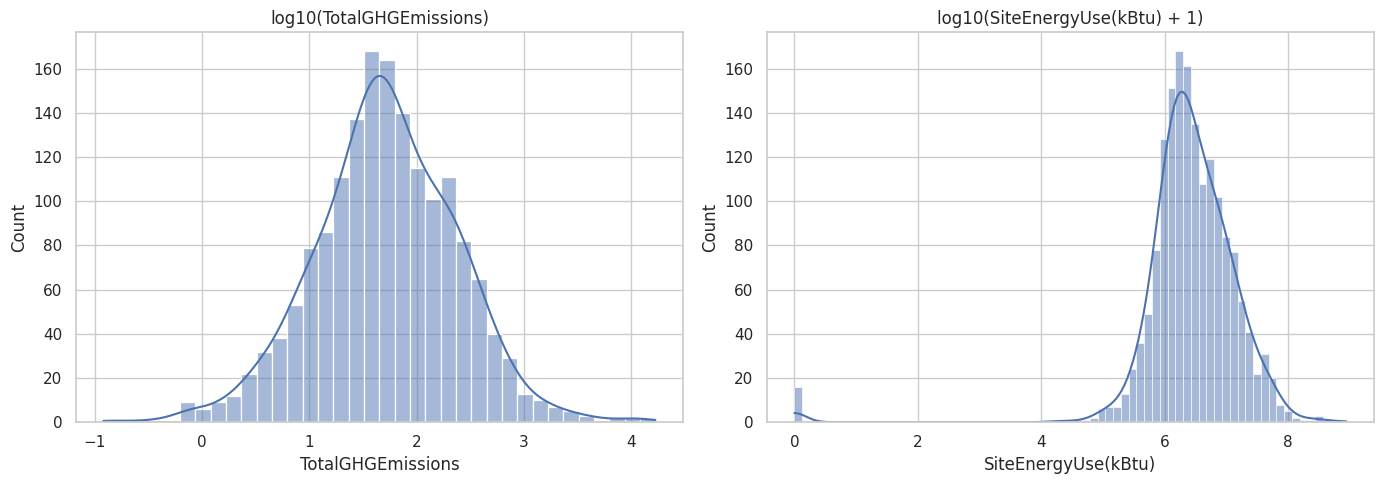

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(np.log10(df_non_res["TotalGHGEmissions"][df_non_res["TotalGHGEmissions"] > 0]), # exlut les valeurs négatives ou nulles
             kde=True, ax=axes[0])
axes[0].set_title("log10(TotalGHGEmissions)")

sns.histplot(np.log10(df_non_res["SiteEnergyUse(kBtu)"] + 1), # +1 car log(0) impossible + permet de garder les observations à 0
             kde=True, ax=axes[1])
axes[1].set_title("log10(SiteEnergyUse(kBtu) + 1)")

plt.tight_layout()
plt.show()

<font size="4"><b>Analyse de la distribution de log10(TotalGHGEmissions)</b></font>

La distribution de **`TotalGHGEmissions`** présente une forme **globalement unimodale et proche d'une distribution en cloche**, avec une concentration majoritaire des observations autour d'une valeur centrale.

On observe :

- une **dispersion modérée** autour du centre,montrant que les niveaux d'émissions diffèrent entre bâtiments sans être totalement dispersés ;
- une **légère asymétrie à droite**, traduisant la présence de bâtiments particulièrement émetteurs, sans qu'ils dominent excessivement la distribution ;
- peu de valeurs extrêmes très isolées, ce qui suggère que la majorité des bâtiments présentent des niveaux d'émissions comparables.

Cette structure indique une distribution **continue, lisse et bien structurée**, favorable à la modélisation statistique et à l'utilisation de modèles de régression, tout en conservant une hétérogénéité réaliste entre bâtiments.

<br>
<font size="4"><b>Analyse de la distribution de log10(SiteEnergyUse(kBtu) + 1)</b></font>

La distribution de **`SiteEnergyUse(kBtu)`** présente également une forme **unimodale**, avec une concentration marquée des observations autour d'une valeur centrale, traduisant un niveau de consommation énergétique dominant parmi les bâtiments étudiés.

On observe :

- une **dispersion modérée** autour du centre, indiquant des différences de consommation entre bâtiments, tout en restant dans un ordre de grandeur comparable ;
- une **asymétrie à droite légèrement plus marquée** que pour les émissions, révélant l'existence de bâtiments particulièrement énergivores ;
- quelques **valeurs plus éloignées**, correspondant à de très grands bâtiments ou à des usages spécifiques, sans pour autant déséquilibrer fortement la distribution globale.

Dans l'ensemble, la distribution apparaît **continue, lisse et bien structurée**, avec une variabilité réaliste entre bâtiments. Cette configuration est favorable à la modélisation, notamment pour des modèles de régression, tout en reflétant la diversité des niveaux de consommation énergétique du parc non résidentiel.

## 1.2. Qualité des données : valeurs manquantes, incohérences et outliers

Cette section vise à évaluer la qualité du jeu de données et à appliquer les premiers traitements de nettoyage.

Les valeurs manquantes, incohérences structurelles et outliers sont analysés conjointement afin de prendre des décisions cohérentes et directement exploitables pour la suite du projet.

### 1.2.1. Analyse et traitement des valeurs manquantes

In [ ]:
# Tableau récapitulatif des valeurs manquantes

missing_summary = (
    df_non_res.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "nb_missing", "mean": "missing_rate"})
    .sort_values("missing_rate", ascending=False)
)

missing_summary[missing_summary["nb_missing"] > 0]

,nb_missing,missing_rate
Outlier,"1,651.00",0.99
YearsENERGYSTARCertified,"1,570.00",0.94
ThirdLargestPropertyUseTypeGFA,"1,315.00",0.79
ThirdLargestPropertyUseType,"1,315.00",0.79
SecondLargestPropertyUseType,813.00,0.49
SecondLargestPropertyUseTypeGFA,813.00,0.49
ENERGYSTARScore,574.00,0.34
ZipCode,16.00,0.01
LargestPropertyUseType,6.00,0.00
LargestPropertyUseTypeGFA,6.00,0.00


<font size="4"><b>Lecture et interprétation des valeurs manquantes</b></font>
<br><br>
1. **Variables très fortement manquantes (> 80 %)**
- `Outlier` (~99 % manquants)
- `YearsENERGYSTARCertified` (~94 %)

Ces variables sont très peu renseignées dans le dataset.

Cela suggère soit :
- une information optionnelle ou non applicable à la majorité des bâtiments,
- soit une donnée collectée de manière incomplète.

→ Elles apportent peu d'information exploitable à ce stade et **ne pourront pas être utilisées telles quelles dans les modèles**.

Un choix devra être fait entre :
- suppression,
- ou utilisation très encadrée (ex. indicateur binaire "renseigné / non renseigné").
<br>

2. **Variables partiellement manquantes (~30-80 %)**
- `ThirdLargestPropertyUseType` / `GFA` (~79 %)
- `SecondLargestPropertyUseType` / `GFA` (~49 %)
- `ENERGYSTARScore` (~34 %)

Ces variables sont absentes pour une part significative des bâtiments, mais restent potentiellement informatives.
- Pour les usages secondaires et tertiaires, l'absence est logique : tous les bâtiments n'ont pas plusieurs usages.
- Pour l'ENERGY STAR Score, l'absence reflète un **manque de calcul ou de certification**, et non une erreur de mesure.

→ Ces variables méritent d'être conservées, avec un traitement adapté :

- gestion explicite des valeurs manquantes,
- ou séparation future des modèles avec / sans ENERGY STAR Score.
<br>

3. **Variables très faiblement manquantes (< 1 %)**
- `ZipCode`
- `LargestPropertyUseType` / `GFA`
- `TotalGHGEmissions`
- `SiteEnergyUse(kBtu)`
- `NumberofBuildings`
- `ListOfAllPropertyUseTypes`

Le nombre de valeurs manquantes est très faible et probablement lié à des erreurs ponctuelles.

→ Ces lignes pourront être :
- supprimées sans impact significatif sur le dataset,
- ou corrigées au cas par cas si nécessaire.
<br>

**Synthèse opérationnelle**

- Certaines variables sont **structurellement peu renseignées** et devront être écartées ou simplifiées.
- D'autres, bien que partiellement manquantes, **restent stratégiques pour la modélisation**.
- Les variables clés (features principales et cibles) sont **quasi complètes**, ce qui est rassurant pour la suite du projet.
___

<font size="4"><b>Traitement des valeurs manquantes</b></font>

**Étape 1 — Suppression des lignes marquées comme outliers**

Les lignes identifiées comme outliers correspondent à des bâtiments atypiques ou non fiables pour la modélisation.

In [ ]:
# Avant
print("Nombre de lignes avant suppression des outliers :", df_non_res.shape[0])

# Suppression des lignes Outlier renseignées
df_non_res = df_non_res[df_non_res["Outlier"].isna()]

# Après
print("Nombre de lignes après suppression des outliers :", df_non_res.shape[0])

Nombre de lignes avant suppression des outliers : 1668
Nombre de lignes après suppression des outliers : 1651


**Étape 2 — Suppression des colonnes Outlier et YearsENERGYSTARCertified**

Ces colonnes sont soit quasi entièrement manquantes, soit non pertinentes pour la modélisation future.

In [ ]:
# Avant
print("Nombre de colonnes avant suppression :", df_non_res.shape[1])

cols_to_drop = ["Outlier", "YearsENERGYSTARCertified"]
df_non_res = df_non_res.drop(columns=[c for c in cols_to_drop if c in df_non_res.columns])

# Après
print("Nombre de colonnes après suppression :", df_non_res.shape[1])

Nombre de colonnes avant suppression : 33
Nombre de colonnes après suppression : 31


**Étape 3 — Traitement des variables partiellement manquantes (usages secondaires)**

Variables concernées :
- `SecondLargestPropertyUseType`, `SecondLargestPropertyUseTypeGFA`
- `ThirdLargestPropertyUseType`, `ThirdLargestPropertyUseTypeGFA`

L'absence de ces valeurs indique généralement qu'il n'existe pas d'usage secondaire ou tertiaire ; une valeur par défaut est donc cohérente.

In [ ]:
# Remplissage des usages manquants
df_non_res["SecondLargestPropertyUseType"] = df_non_res["SecondLargestPropertyUseType"].fillna("None")
df_non_res["ThirdLargestPropertyUseType"] = df_non_res["ThirdLargestPropertyUseType"].fillna("None")

df_non_res["SecondLargestPropertyUseTypeGFA"] = df_non_res["SecondLargestPropertyUseTypeGFA"].fillna(0)
df_non_res["ThirdLargestPropertyUseTypeGFA"] = df_non_res["ThirdLargestPropertyUseTypeGFA"].fillna(0)

**Étape 4 — Traitement de l'ENERGYSTARScore**

La variable est partiellement manquante mais sera testée dans certaines modélisations ; les valeurs manquantes sont conservées et traitées ultérieurement.

In [ ]:
# Aucune modification à ce stade
df_non_res["ENERGYSTARScore"].isna().mean()

np.float64(0.34403391883706846)

**Étape 5 — Suppression des lignes très faiblement manquantes**

Variables concernées (manquantes très rares) :
- `ZipCode`, `LargestPropertyUseType`, `LargestPropertyUseTypeGFA`,
- `TotalGHGEmissions`, `SiteEnergyUse(kBtu)`, `NumberofBuildings`, `ListOfAllPropertyUseTypes`

Le faible nombre de lignes concernées permet une suppression sans impact significatif sur le volume de données.

In [ ]:
# Avant
print("Nombre de lignes avant suppression des NA résiduels :", df_non_res.shape[0])

low_missing_cols = [
    "ZipCode",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "TotalGHGEmissions",
    "SiteEnergyUse(kBtu)",
    "NumberofBuildings",
    "ListOfAllPropertyUseTypes"
]

df_non_res = df_non_res.dropna(subset=[c for c in low_missing_cols if c in df_non_res.columns])

# Après
print("Nombre de lignes après suppression des NA résiduels :", df_non_res.shape[0])

Nombre de lignes avant suppression des NA résiduels : 1651
Nombre de lignes après suppression des NA résiduels : 1629


### 1.2.2. Incohérences structurelles (zéros et valeurs impossibles)

L'objectif de cette étape est d'identifier et de traiter les **valeurs structurellement incohérentes**, c'est-à-dire des valeurs possibles techniquement dans le dataset, mais **non plausibles d'un point de vue métier**.

**Étape 1 - Bâtiments avec surface nulle ou négative**

Une surface totale nulle ou négative n'a pas de sens pour un bâtiment non résidentiel et empêche toute analyse énergétique cohérente.

In [ ]:
# Avant
print("Nombre de lignes avant filtrage surface :", df_non_res.shape[0])

df_non_res = df_non_res[df_non_res["PropertyGFATotal"] > 0]

# Après
print("Nombre de lignes après filtrage surface :", df_non_res.shape[0])

Nombre de lignes avant filtrage surface : 1629
Nombre de lignes après filtrage surface : 1629


**Étape 2 - Nombre d'étages ou de bâtiments égal à zéro**

Un nombre d'étages ou de bâtiments égal à zéro est incohérent et peut perturber la modélisation.

In [ ]:
# Avant
print("Nombre de lignes avant filtrage étages :", df_non_res.shape[0])

df_non_res = df_non_res[(df_non_res["NumberofFloors"] > 0) &
                        (df_non_res["NumberofBuildings"] > 0)
                        ]

# Après
print("Nombre de lignes après filtrage étages :", df_non_res.shape[0])

Nombre de lignes avant filtrage étages : 1629
Nombre de lignes après filtrage étages : 1562


**Étape 3 - Incohérences entre surfaces (GFA)**

La surface totale du bâtiment doit être égale à la surface bâtie principale plus la surface de parking.

In [ ]:
# Avant
print("Nombre de lignes avant filtrage GFA :", df_non_res.shape[0])

df_non_res = df_non_res[
    (df_non_res["PropertyGFATotal"] == df_non_res["PropertyGFABuilding(s)"] + df_non_res["PropertyGFAParking"])
]

# Après
print("Nombre de lignes après filtrage GFA :", df_non_res.shape[0])

Nombre de lignes avant filtrage GFA : 1562
Nombre de lignes après filtrage GFA : 1562


**Étape 4 - Valeurs négatives des cibles énergétiques**

Certaines observations présentent des valeurs négatives pour **`TotalGHGEmissions`** ou **`SiteEnergyUse(kBtu)`**, ce qui n'a pas de sens physique pour des émissions ou une consommation d'énergie. Ces lignes sont donc supprimées afin de garantir la cohérence des données utilisées pour la modélisation.

In [ ]:
# Avant
n_before = df_non_res.shape[0]

df_non_res = df_non_res[
    (df_non_res["TotalGHGEmissions"] >= 0) &
    (df_non_res["SiteEnergyUse(kBtu)"] >= 0)
]

# Après
n_after = df_non_res.shape[0]

print(f"Lignes supprimées (valeurs négatives des cibles) : {n_before - n_after}")
print(f"Nombre de lignes restantes : {n_after}")

Lignes supprimées (valeurs négatives des cibles) : 1
Nombre de lignes restantes : 1561


**Étape 5 - Vérification rapide post-traitement**

In [ ]:
df_non_res[[
    "PropertyGFATotal",
    "PropertyGFABuilding(s)",
    "PropertyGFAParking",
    "NumberofFloors",
    "NumberofBuildings",
    "TotalGHGEmissions",
    "SiteEnergyUse(kBtu)"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
PropertyGFATotal,"1,561.00","113,360.09","193,749.02","16,300.00","30,000.00","49,950.00","105,061.00","2,200,000.00"
PropertyGFABuilding(s),"1,561.00","99,974.74","171,129.24","3,636.00","28,800.00","47,415.00","94,470.00","2,200,000.00"
PropertyGFAParking,"1,561.00","13,385.34","43,226.72",0.00,0.00,0.00,0.00,"512,608.00"
NumberofFloors,"1,561.00",4.22,6.71,1.00,1.00,2.00,4.00,99.00
NumberofBuildings,"1,561.00",1.13,1.14,1.00,1.00,1.00,1.00,27.00
TotalGHGEmissions,"1,561.00",178.19,720.89,0.00,20.08,49.58,138.35,"16,870.98"
SiteEnergyUse(kBtu),"1,561.00","7,897,430.16","21,981,197.34",0.00,"1,245,923.75","2,553,763.50","6,876,439.50","448,385,312.00"


Les statistiques descriptives après nettoyage montrent que les incohérences majeures ont été corrigées :
les surfaces, le nombre de bâtiments et d'étages présentent désormais des valeurs strictement positives, et les valeurs négatives des consommations et émissions ont été supprimées. Les distributions restent très étalées, avec des maximums élevés, ce qui confirme la présence de bâtiments atypiques mais plausibles à l'échelle de la ville.

Ces résultats indiquent que le jeu de données est désormais **structurellement cohérent**, tout en conservant une hétérogénéité réaliste. La prochaine étape consiste à analyser plus finement les outliers déclarés afin de décider s'ils doivent être conservés ou exclus pour la modélisation.
___

### 1.2.3. Analyse et traitement des outliers

#### 1.2.3.1. Rappel sur le traitement des outliers déclarés

Les observations explicitement marquées comme outliers via la variable `Outlier` ont été supprimées lors des étapes précédentes de nettoyage.

Cette décision permet de partir d'un jeu de données plus fiable pour l'analyse exploratoire et la modélisation, sans dépendre uniquement de méthodes statistiques automatiques.

#### 1.2.3.2. Analyse du statut de conformité (`ComplianceStatus`)

La variable **`ComplianceStatus`** indique si un bâtiment respecte les obligations de reporting énergétique.

In [ ]:
df_non_res["ComplianceStatus"].value_counts(dropna=False)

,count
ComplianceStatus,
Compliant,1463
Error - Correct Default Data,83
Missing Data,14
Non-Compliant,1


<font size="4"><b>Lecture des résultats</b></font>

- **La très grande majorité des bâtiments est conforme** (*Compliant* : 1463 observations), ce qui constitue une base solide pour la modélisation.
- Les statuts ***Error - Correct Default Data*** (83) et ***Missing Data*** (14) correspondent à des bâtiments pour lesquels certaines informations ont été corrigées automatiquement ou restent incomplètes, ce qui peut introduire des incertitudes dans les données.
- Le statut ***Non-Compliant*** est marginal (1 seule observation) et indique un non-respect des obligations de conformité.

→ Ces statuts signalent des **problèmes de qualité ou de fiabilité des données**, indépendants des valeurs manquantes déjà traitées précédemment.

<br>
<font size="4"><b>Décision retenue</b></font>

Afin de garantir un jeu de données cohérent et fiable pour l'apprentissage des modèles :
- **Seuls les bâtiments avec un statut *Compliant* sont conservés**.
- Les autres statuts sont exclus, car ils reflètent des anomalies de conformité ou des informations peu fiables, susceptibles de dégrader les performances du modèle.
- La colonne `ComplianceStatus` est ensuite supprimée, car elle n'a plus d'utilité explicative une fois le filtrage effectué.

In [ ]:
# Nombre d'observations avant filtrage
print("Nombre de lignes avant filtrage :", df_non_res.shape[0])

# Conservation uniquement des bâtiments conformes
df_non_res = df_non_res[df_non_res["ComplianceStatus"] == "Compliant"].copy()

# Suppression de la colonne ComplianceStatus
df_non_res.drop(columns=["ComplianceStatus"], inplace=True)

# Nombre d'observations après filtrage
print("Nombre de lignes après filtrage :", df_non_res.shape[0])

Nombre de lignes avant filtrage : 1561
Nombre de lignes après filtrage : 1463


#### 1.2.3.3. Détection des outliers restants

Après le traitement des outliers déclarés et la gestion du statut de conformité, une dernière vérification est réalisée afin d'identifier d'éventuelles valeurs extrêmes restantes dans les données numériques et valeures anormales dans les variables catégorielles.

<font size="4"><b>Analyse succincte des variables numériques</b></font>

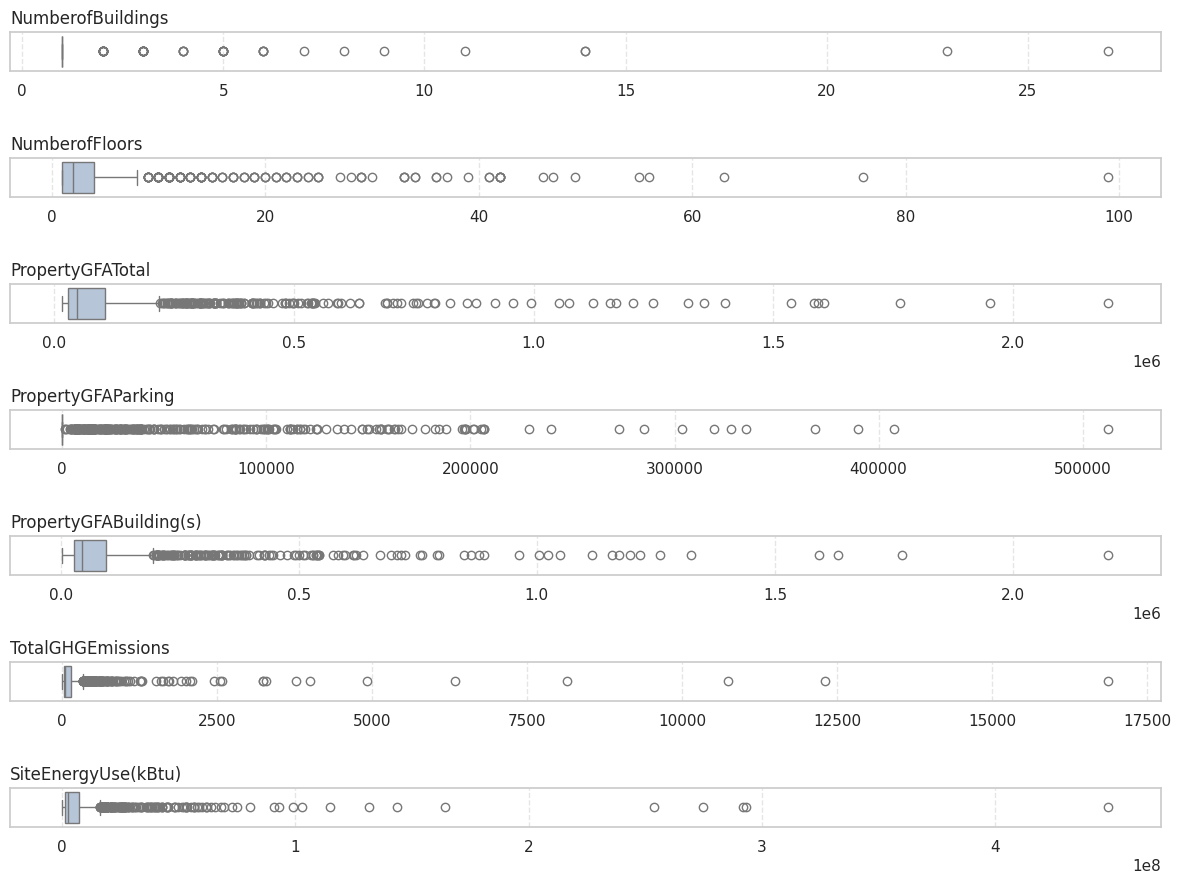

In [ ]:
num_cols_to_check = [
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "TotalGHGEmissions",
    "SiteEnergyUse(kBtu)"
]

fig, axes = plt.subplots(
    nrows=len(num_cols_to_check),
    ncols=1,
    figsize=(12, 9)
)

for ax, col in zip(axes, num_cols_to_check):
    sns.boxplot(
        x=df_non_res[col],
        ax=ax,
        color="lightsteelblue"
    )
    ax.set_title(col, loc="left")
    ax.set_xlabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

Les diagrammes en boîte montrent que l'ensemble des variables numériques étudiées présente des distributions **fortement étalées vers la droite**, avec une majorité d'observations concentrées sur des valeurs relativement faibles et une queue droite longue.

Les points situés au-delà des moustaches correspondent à des observations **atypiques mais plausibles**, reflétant la forte hétérogénéité des bâtiments non résidentiels (grands complexes, bâtiments très hauts ou très énergivores). Ces valeurs ne traduisent pas nécessairement des erreurs de mesure, mais plutôt des cas extrêmes réels.

En l'absence d'anomalies manifestes ou de ruptures nettes dans les distributions, **aucune suppression automatique de ces observations n'est effectuée à ce stade**. Elles sont conservées afin de préserver la diversité du parc immobilier étudié. Un filtrage plus strict pourra être envisagé ultérieurement si ces valeurs ont un impact négatif sur la stabilité ou la performance des modèles.
___

<font size="4"><b>Analyse des variables catégorielles</b></font>

Parmi les variables catégorielles disponibles, seules celles **porteuses d'information métier ou structurelle** sont retenues pour l'analyse. L'objectif est d'identifier les catégories susceptibles d'expliquer des différences de consommation énergétique ou d'émissions, tout en écartant les variables purement descriptives ou identifiantes.

En particulier :

- **Variables liées à l'usage et à la fonction du bâtiment** (`BuildingType`, `PrimaryPropertyType`, `LargestPropertyUseType`, `SecondLargestPropertyUseType`, `ThirdLargestPropertyUseType`)

  → directement liées aux profils de consommation et d'émissions.

- **Variables de localisation** (`Neighborhood`, `CouncilDistrictCode`)
  
  → permettent de capter des effets géographiques ou urbains.

- **Variable de performance énergétique** (`ENERGYSTARScore`)
  
  → analysée spécifiquement compte tenu de son rôle central dans le projet.

Les variables telles que `PropertyName`, `Address`, `TaxParcelIdentificationNumber`, `City` ou `State` sont écartées de l'analyse catégorielle car elles n'apportent pas d'information exploitable pour la modélisation et relèvent principalement de l'identification administrative.

Cette sélection permet de concentrer l'analyse sur des variables interprétables, pertinentes et directement mobilisables dans les étapes suivantes de feature engineering et de modélisation.


**Étape 1 - Variables liées à l'usage et à la fonction du bâtiment**

Ces variables décrivent l'activité principale et secondaire du bâtiment, directement liées aux profils énergétiques.

In [ ]:
usage_categorical = [
    "BuildingType",
    "PrimaryPropertyType",
    "LargestPropertyUseType",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType"
]

for col in usage_categorical:
    print(f"\n{col}")
    print(df_non_res[col].value_counts())


BuildingType
BuildingType
NonResidential        1370
Nonresidential COS      60
Campus                  22
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64

PrimaryPropertyType
PrimaryPropertyType
Small- and Mid-Sized Office    273
Other                          219
Warehouse                      181
Large Office                   165
Mixed Use Property             103
Retail Store                    82
Hotel                           71
Worship Facility                68
Distribution Center             53
K-12 School                     50
Supermarket / Grocery Store     38
Medical Office                  34
Self-Storage Facility           27
University                      23
Senior Care Community           20
Residence Hall                  16
Refrigerated Warehouse          11
Restaurant                      10
Hospital                         9
Laboratory                       8
Low-Rise Multifamily             2
Name: count, dtype: int64

LargestPr

1. **`BuildingType`**

La quasi-totalité des observations appartient à ***NonResidential***, avec quelques catégories annexes (*Nonresidential COS*, *Campus*, *SPS-District K-12*).

→ **Toutes ces catégories représentent bien des bâtiments non résidentiels**, donc **aucune suppression n'est nécessaire** à ce stade.

<br>

2. **`PrimaryPropertyType` et `LargestPropertyUseType`**

La distribution de **`PrimaryPropertyType`** montre une grande variété de types de bâtiments (bureaux, entrepôts, hôtels, commerces, hôpitaux…). La majorité des usages sont bien cohérents avec le périmètre non résidentiel de la mission.

Cependant, la **variable `LargestPropertyUseType` contient quelques occurrences de "*Multifamily Housing*"**, c'est-à-dire du logement collectif, ce qui pourrait indiquer que certains bâtiments du dataset sont en réalité des bâtiments résidentiels déguisés ou à usage mixte.

→ **Si ces bâtiments n'ont aucun autre usage non résidentiel**, ils ne doivent pas être conservés pour la suite du projet.

Une vérification complémentaire sera donc menée :

- identifier les bâtiments dont l'**unique usage** est résidentiel (`LargestPropertyUseType = Multifamily Housing` **ET** pas d'autre usage secondaire pertinent),

- puis décider de leur suppression s'ils sont effectivement hors périmètre.

<br>

3. **`SecondLargest` / `ThirdLargestPropertyUseType`**

Ces variables décrivent les **différents usages** présents dans un même bâtiment. L'analyse met en évidence :
- Une forte majorité de "None" en SecondLargest et ThirdLargest → **normal**, car beaucoup de bâtiments ont un seul usage principal.
- Une diversité importante dans les usages secondaires et tertiaires.
- Certaines catégories très rares (1 à 3 occurrences), mais cela est attendu pour des usages très spécifiques (ex : Police Station, Fire Station, Courthouse…).

→ **Aucune suppression à ce stade :** ces catégories rares ne gênent pas l'analyse et pourront être gérées plus tard via un regroupement ou un encodage adapté.

**Observations résidentielles résiduelles**

In [ ]:
df_non_res[(df_non_res["LargestPropertyUseType"] == "Multifamily Housing") & (df_non_res["SecondLargestPropertyUseType"] == "None")]

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUse(kBtu),DefaultData,TotalGHGEmissions
644,19445,NonResidential,Low-Rise Multifamily,Pacific Pointe,2108 N Pacific St.,Seattle,WA,"98,103.00",0354000254,4,LAKE UNION,47.65,-122.33,2000,1.00,3,93079,36093,56986,Multifamily Housing,Multifamily Housing,"91,064.00",None,0.00,None,0.00,32.00,"1,997,181.50",False,25.60


L'examen du jeu de données montre qu'**une seule observation** possède exclusivement un usage de type *Multifamily Housing* (`LargestPropertyUseType = "Multifamily Housing"` et `SecondLargestPropertyUseType = "None"`).

Ce type d'usage correspond à un bâtiment **strictement résidentiel**, qui ne rentre pas dans le périmètre du projet portant sur les bâtiments non destinés à l'habitation.

Cette observation isolée est donc retirée du dataset pour conserver un périmètre cohérent.

In [ ]:
# Avant
print("Nombre de lignes avant suppression : " + str(df_non_res.shape[0]))

# Suppression
df_non_res = df_non_res[~((df_non_res["LargestPropertyUseType"] == "Multifamily Housing") & (df_non_res["SecondLargestPropertyUseType"] == "None"))].copy()

# Après
print("Nombre de lignes après suppression : " + str(df_non_res.shape[0]))

Nombre de lignes avant suppression : 1463
Nombre de lignes après suppression : 1462


**Étape 2 — Variables de localisation**

Ces variables permettent de capter d'éventuels effets géographiques ou urbains.

In [ ]:
location_categorical = [
    "Neighborhood",
    "CouncilDistrictCode"
]

for col in location_categorical:
    print(f"\n{col}")
    print(df_non_res[col].value_counts().head(10))


Neighborhood
Neighborhood
DOWNTOWN                 332
GREATER DUWAMISH         318
MAGNOLIA / QUEEN ANNE    140
LAKE UNION               136
NORTHEAST                107
EAST                     104
NORTHWEST                 71
BALLARD                   54
NORTH                     47
CENTRAL                   38
Name: count, dtype: int64

CouncilDistrictCode
CouncilDistrictCode
7    491
2    353
3    172
4    145
5    113
6     96
1     92
Name: count, dtype: int64


1. **`Neighborhood`**

La variable `Neighborhood` présente une répartition assez déséquilibrée entre zones, avec une forte concentration dans les quartiers centraux et économiques de Seattle :

- **DOWNTOWN (332)** et **GREATER DUWAMISH (318)** regroupent à eux seuls près de la majorité des bâtiments non résidentiels, ce qui reflète leur densité d'activités tertiaires, industrielles et logistiques.

Les zones comme **MAGNOLIA/QUEEN ANNE**, **LAKE UNION**, et **NORTHEAST** affichent des effectifs intermédiaires.

Les quartiers plus périphériques (**BALLARD**, **NORTHWEST**, **NORTH**, **CENTRAL**) sont nettement moins représentés.

→ **Intérêt pour la modélisation :**

Ces variations spatiales peuvent capturer des différences d'infrastructure énergétique, de type d'usage urbanistique ou de contraintes climatiques locales. La variable est donc pertinente et sera conservée.

<br>

2. **`CouncilDistrictCode`**

Les *Council Districts* montrent également une distribution inégale :
- Le district **7** (491 bâtiments) domine largement, suivi des districts **2** (353) et **3** (172).

Les districts **5**, **6** et surtout **1** sont moins représentés.

→ **Intérêt pour la modélisation :**
Ce découpage administratif reflète des zones aux profils socio-économiques et urbanistiques différents, susceptibles d'influencer la consommation énergétique et les émissions.
La variable sera également conservée.

<br>

**Conclusion**

Les deux variables de localisation présentent une **variabilité significative** et une structure cohérente avec l'aménagement urbain de Seattle. Elles sont **informatives**, non redondantes et potentiellement utiles pour capturer des effets géographiques dans les futurs modèles de prédiction.
___

**Étape 3 - Variable de performance énergétique**

Cette variable est analysée séparément compte tenu de son rôle central dans le projet.

In [ ]:
df_non_res["ENERGYSTARScore"].describe()

,ENERGYSTARScore
count,960.00
mean,63.93
std,28.83
min,1.00
25%,45.00
50%,71.00
75%,89.00
max,100.00


L'`ENERGYSTARScore` est disponible pour une partie des bâtiments uniquement (960 observations), ce qui implique un traitement spécifique des valeurs manquantes.

La distribution est assez étendue (écart-type ≈ 29), avec une médiane élevée (71), indiquant que de nombreux bâtiments affichent de bonnes performances énergétiques.

La présence de scores faibles (minimum = 1) traduit toutefois une forte hétérogénéité des performances, faisant de cette variable un indicateur potentiellement discriminant pour la modélisation, sous réserve d'une gestion adaptée des valeurs manquantes.
___

**Étape 4 - Suppression des variables catégorielles non pertinentes**

Les variables suivantes sont écartées car elles relèvent principalement de l'identification administrative et n'apportent pas d'information exploitable pour la modélisation.

In [ ]:
categorical_to_drop = [
    "PropertyName",
    "Address",
    "TaxParcelIdentificationNumber",
    "City",
    "State"
]

print("Colonnes avant suppression :", df_non_res.shape[1])

df_non_res = df_non_res.drop(columns=categorical_to_drop)

print("Colonnes après suppression :", df_non_res.shape[1])

Colonnes avant suppression : 30
Colonnes après suppression : 25


## 1.3. Distributions, relations importantes et premières pistes de feature engineering

Cette section vise à explorer les relations principales entre les variables explicatives et les cibles, tout en mettant en place les premières transformations simples de feature engineering.

L'objectif n'est pas d'optimiser les performances à ce stade, mais de construire des variables cohérentes, interprétables et utiles pour les modèles à venir.

### 1.3.1. Cohérence entre les usages principaux et la surface totale du bâtiment

**Objectif :**

Vérifier que les **trois principaux usages** représentent bien l'essentiel de la surface totale du bâtiment, afin de pouvoir **supprimer** `ListOfAllPropertyUseTypes` ensuite.

In [ ]:
# Ratio de surface occupée par les 3 usages principaux
df_non_res["MainUses_GFA_Ratio"] = (
    df_non_res["LargestPropertyUseTypeGFA"]
    + df_non_res["SecondLargestPropertyUseTypeGFA"]
    + df_non_res["ThirdLargestPropertyUseTypeGFA"]
) / df_non_res["PropertyGFATotal"]

df_non_res["MainUses_GFA_Ratio"].describe()

,MainUses_GFA_Ratio
count,"1,462.00"
mean,1.01
std,0.29
min,0.22
25%,0.98
50%,1.00
75%,1.00
max,6.43


Le ratio entre la surface cumulée des trois principaux usages et la surface totale du bâtiment est très proche de 1 pour la grande majorité des observations (médiane = 1, quartiles très resserrés).
Cela indique que les trois usages principaux couvrent généralement l'essentiel de la surface des bâtiments.

Quelques valeurs supérieures à 1 traduisent probablement des incohérences de déclaration ou des arrondis, sans remettre en cause la tendance générale.

<font size="4"><b>Analyse des ratios anormaux</b></font>

La majorité des bâtiments présentent un ratio proche de 1.
Cependant, un petit nombre d'observations présente des ratios **anormalement faibles ou élevés**, suggérant :
- une incohérence de surface,
- une déclaration incomplète des usages,
- ou une erreur de saisie.

Afin de rester prudent, des **seuils larges** sont retenus :
- ratio < 0.5
- ratio > 1.5

Ces seuils permettent de ne cibler que les cas manifestement incohérents et clairement problématiques.

In [ ]:
mask_suspect = (
    (
        (df_non_res["MainUses_GFA_Ratio"] < 0.5)
        & (df_non_res["ThirdLargestPropertyUseType"] == "None"))
    | (df_non_res["MainUses_GFA_Ratio"] > 1.5)
    )

df_non_res[mask_suspect].shape[0]

60

<font size="4"><b>Interprétation</b></font>

- Les ratios **très supérieurs à 1** indiquent une incohérence directe entre surfaces déclarées et surface totale.
- Les ratios **très inférieurs à 1**, combinés à l'absence de troisième usage (`ThirdLargestPropertyUseType == "None"`), suggèrent que :
  - les usages principaux ne couvrent pas la surface réelle,
  - et qu'aucune information complémentaire ne permet de corriger l'écart.

Ces observations sont donc **peu fiables** et risqueraient de biaiser les modèles.

<br>
<font size="4"><b>Décision</b></font>

→ **Suppression des 60 observations concernées**, afin de garantir la cohérence des variables de surface utilisées en feature engineering.

In [ ]:
## Avant
print("Taille du dataset avant suppression :", df_non_res.shape)

df_non_res = df_non_res[~mask_suspect].copy()


## Après
print("Taille du dataset après suppression :", df_non_res.shape)

Taille du dataset avant suppression : (1462, 26)
Taille du dataset après suppression : (1402, 26)


<font size="4"><b>Suppression de la variable `ListOfAllPropertyUseTypes`</b></font>

Après vérification, les **trois usages principaux** couvrent correctement la surface des bâtiments restants.

La variable `ListOfAllPropertyUseTypes`, plus complexe et redondante, n'apporte donc pas d'information supplémentaire exploitable pour la modélisation.

In [ ]:
## Avant
print("Colonnes avant suppression :", df_non_res.shape[1])

df_non_res.drop(columns=["ListOfAllPropertyUseTypes"], inplace=True)

## Après
print("Colonnes après suppression :", df_non_res.shape[1])

Colonnes avant suppression : 26
Colonnes après suppression : 25


### 1.3.2. Encodage des usages principaux (Largest / Second / Third)

On encode les usages principaux sous forme de variables binaires indiquant la **présence** d'un usage parmi les trois activités principales, indépendamment de leur rang (1er/2e/3e), afin de capturer plus simplement le profil fonctionnel de chaque bâtiment.

In [ ]:
use_cols = ["LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType"]

# Création d'une liste d'usages par bâtiment (en retirant "None" et les NaN)
uses_series = (
    df_non_res[use_cols]
    .apply(lambda row: [u for u in row.tolist() if u != "None"], axis=1)
)

# One-hot encoding multi-valeur : explode + crosstab
uses_exploded = uses_series.explode()                        # Passe d'une liste par ligne à une ligne par usage
use_ohe = pd.crosstab(uses_exploded.index, uses_exploded)    # Matrice avec en ligne les index, en colonne les usages

# Conversion des coocurences en valeurs binaires
use_ohe = (use_ohe > 0).astype(int)                          # Convertit en True/False puis en 1/0

# Renommage des colonnes pour être explicites
use_ohe = use_ohe.add_prefix("Use_")

# Intégration dans le dataframe
df_non_res = df_non_res.join(use_ohe)

# Vérification rapide
print(use_ohe.shape)
df_non_res.filter(like="Use_").head()

(1402, 61)


,Use_Adult Education,Use_Automobile Dealership,Use_Bank Branch,Use_Bar/Nightclub,Use_College/University,Use_Convenience Store without Gas Station,Use_Courthouse,Use_Data Center,Use_Distribution Center,Use_Enclosed Mall,Use_Fast Food Restaurant,Use_Financial Office,Use_Fire Station,Use_Fitness Center/Health Club/Gym,Use_Food Sales,Use_Food Service,Use_Hospital (General Medical & Surgical),Use_Hotel,Use_K-12 School,Use_Laboratory,Use_Library,Use_Lifestyle Center,Use_Manufacturing/Industrial Plant,Use_Medical Office,Use_Movie Theater,Use_Multifamily Housing,Use_Museum,Use_Non-Refrigerated Warehouse,Use_Office,Use_Other,Use_Other - Education,Use_Other - Entertainment/Public Assembly,Use_Other - Lodging/Residential,Use_Other - Mall,Use_Other - Public Services,Use_Other - Recreation,Use_Other - Restaurant/Bar,Use_Other - Services,Use_Other - Technology/Science,Use_Other - Utility,Use_Other/Specialty Hospital,Use_Parking,Use_Performing Arts,"Use_Personal Services (Health/Beauty, Dry Cleaning, etc)",Use_Police Station,Use_Pre-school/Daycare,Use_Refrigerated Warehouse,"Use_Repair Services (Vehicle, Shoe, Locksmith, etc)",Use_Residence Hall/Dormitory,Use_Residential Care Facility,Use_Restaurant,Use_Retail Store,Use_Self-Storage Facility,Use_Senior Care Community,Use_Social/Meeting Hall,Use_Strip Mall,Use_Supermarket/Grocery Store,Use_Swimming Pool,Use_Urgent Care/Clinic/Other Outpatient,Use_Vocational School,Use_Worship Facility
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


À ce stade, l'encodage des usages principaux, secondaires et tertiaires est volontairement conservé sous une forme détaillée. La sélection ou la réduction éventuelle de ces variables sera envisagée ultérieurement, en fonction de leur impact réel sur les performances des modèles.

<font size="4"><b>Suppression des colonnes initiales</b></font>

In [ ]:
## Avant
print("Colonnes avant suppression :", df_non_res.shape[1])

df_non_res.drop(columns=[
    "LargestPropertyUseType",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType"
], inplace=True)

## Après
print("Colonnes après suppression :", df_non_res.shape[1])

Colonnes avant suppression : 86
Colonnes après suppression : 83


### 1.3.3. Création de l'âge du bâtiment

L'année de construction brute (`YearBuilt`) est peu interprétable telle quelle par un modèle.

L'**âge du bâtiment** est calculé comme la différence entre l'année des données (**2016**) et l'année de construction.

La variable `YearBuilt` a été remplacée par l'âge du bâtiment. Cette transformation permet de conserver une information plus directement exploitable par les modèles tout en évitant une redondance inutile entre variables fortement corrélées.

In [ ]:
# Création de l'âge du bâtiment (référence : année des données = 2016)
df_non_res["BuildingAge"] = 2016 - df_non_res["YearBuilt"]

# Suppression de YearBuilt
df_non_res = df_non_res.drop(columns=["YearBuilt"])

# Vérification rapide
df_non_res["BuildingAge"].describe()

,BuildingAge
count,"1,402.00"
mean,54.78
std,32.75
min,1.00
25%,28.00
50%,51.00
75%,87.00
max,116.00


### 1.3.4. Création des ratios de surface

<font size="4"><b>Pourquoi créer ces ratios ?</b></font>

- Les surfaces brutes (GFA total, parking, bâtiment…) sont **très liées entre elles** : plus un bâtiment est grand, plus *tout* est grand.

- Les **ratios** capturent plutôt la **structure** du bâtiment (proportions), donc des infos plus comparables entre bâtiments (ex. "beaucoup de parking" vs "peu de parking"), ce qui peut être très explicatif pour l'énergie/les émissions.

De plus, les ratios peuvent **réduire partiellement la corrélation** des variables de taille, car ils décrivent une proportion plutôt qu'un volume.

<br>
<font size="4"><b>Ratios intéressants</b></font>

- **Part du parking**
  - Hypothèse : les bâtiments avec beaucoup de parking ont un profil d'usage différent.
- **Part "bâtiment" vs total** (souvent redondant avec 1), mais utile comme contrôle.
- **Parts des usages principaux**
  - Proportion de surface occupée par l'usage principal / second / troisième (quand présent).
  - Hypothèse : un bâtiment "mixte" n'a pas le même comportement qu'un bâtiment mono-usage.

In [ ]:
# Sécurité division : éviter /0
gfa_total = df_non_res["PropertyGFATotal"].replace(0, np.nan)

# Ratios structurels
df_non_res["Ratio_Parking_GFA"] = df_non_res["PropertyGFAParking"] / gfa_total
df_non_res["Ratio_Building_GFA"] = df_non_res["PropertyGFABuilding(s)"] / gfa_total

# Ratios liés aux usages
df_non_res["Ratio_LargestUse_GFA"] = df_non_res["LargestPropertyUseTypeGFA"] / gfa_total
df_non_res["Ratio_SecondaryUses_GFA"] = (df_non_res["SecondLargestPropertyUseTypeGFA"] + df_non_res["ThirdLargestPropertyUseTypeGFA"]) / gfa_total

# Remplissage des ratios impossibles à calculer (si GFA total manquant/0)
ratio_cols = [
    "Ratio_Parking_GFA",
    "Ratio_Building_GFA",
    "Ratio_LargestUse_GFA",
    "Ratio_SecondaryUses_GFA"
]
df_non_res[ratio_cols] = df_non_res[ratio_cols].fillna(0)

df_non_res[ratio_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Ratio_Parking_GFA,"1,402.00",0.07,0.14,0.00,0.00,0.00,0.00,0.90
Ratio_Building_GFA,"1,402.00",0.93,0.14,0.10,1.00,1.00,1.00,1.00
Ratio_LargestUse_GFA,"1,402.00",0.84,0.21,0.19,0.68,0.94,1.00,1.50
Ratio_SecondaryUses_GFA,"1,402.00",0.14,0.18,0.00,0.00,0.00,0.28,0.86


### 1.3.5. Encodage et nettoyage des variables catégorielles restantes

À ce stade, il reste à traiter les variables catégorielles **`BuildingType`** et **`Neighborhood`** via un encodage One-Hot, afin de rendre ces informations exploitables par les modèles.

En parallèle, certaines variables catégorielles/booléennes sont supprimées car elles n'apportent pas d'information utile :
- **`DefaultData`** ne contient qu'une seule modalité (False), donc elle est non-informative.
- **`PrimaryPropertyType`** est redondante avec les usages déjà encodés via Largest/Second/Third (désormais regroupés dans les colonnes `Use_...`).

In [ ]:
# 1) Suppression des colonnes non informatives / redondantes
cols_to_drop = []

# DefaultData
if "DefaultData" in df_non_res.columns and df_non_res["DefaultData"].nunique(dropna=False) == 1:
    cols_to_drop.append("DefaultData")

# PrimaryPropertyType
if "PrimaryPropertyType" in df_non_res.columns:
    cols_to_drop.append("PrimaryPropertyType")

df_non_res.drop(columns=cols_to_drop, inplace=True, errors="ignore")
print(f"Colonnes supprimées : {cols_to_drop}")

# 2) One-Hot Encoding des variables catégorielles restantes
cat_cols_to_ohe = [c for c in ["BuildingType", "Neighborhood"] if c in df_non_res.columns]

df_non_res = pd.get_dummies(
    df_non_res,
    columns=cat_cols_to_ohe,
    prefix=cat_cols_to_ohe,
    drop_first=True,   # on supprime une modalité pour les modèles linéaires
    dtype=int
)

print("Nouvelle forme du dataframe :", df_non_res.shape)

# 3) Vérification rapide : aperçu des nouvelles colonnes créées
created_cols = [c for c in df_non_res.columns if any(c.startswith(p + "_") for p in ["BuildingType", "Neighborhood"])]
print(f"Nouvelles colonnes créées : {len(created_cols)}")
df_non_res[created_cols].head()

Colonnes supprimées : ['DefaultData', 'PrimaryPropertyType']
Nouvelle forme du dataframe : (1402, 104)
Nouvelles colonnes créées : 21


,BuildingType_NonResidential,BuildingType_Nonresidential COS,BuildingType_Nonresidential WA,BuildingType_SPS-District K-12,Neighborhood_Ballard,Neighborhood_CENTRAL,Neighborhood_Central,Neighborhood_DELRIDGE,Neighborhood_DOWNTOWN,Neighborhood_Delridge,Neighborhood_EAST,Neighborhood_GREATER DUWAMISH,Neighborhood_LAKE UNION,Neighborhood_MAGNOLIA / QUEEN ANNE,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_North,Neighborhood_Northwest,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST
0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


À ce stade, les variables catégorielles **`BuildingType`** et **`Neighborhood`** ont été correctement encodées via One-Hot Encoding.

Elles ne sont donc plus nécessaires sous leur forme initiale et peuvent être supprimées afin d'éviter toute redondance et de simplifier le jeu de données pour les étapes suivantes.

In [ ]:
df_non_res.drop(columns=cat_cols_to_ohe, inplace=True, errors="ignore")
print(f"Colonnes supprimées : {cat_cols_to_ohe}")

Colonnes supprimées : ['BuildingType', 'Neighborhood']


Le dataset est désormais **entièrement numérique**, cohérent, et prêt pour :
- l'analyse des distributions,
- l'étude des corrélations,
- et la modélisation.
___

### 1.3.6. Distributions, corrélations et relations avec les cibles

Cette section vise à :
- vérifier les **distributions des variables numériques finales** après feature engineering,
- analyser les **corrélations entre features et cibles**,
- observer les **relations simples entre certaines variables clés et les cibles**, afin d'anticiper les choix de modèles et de transformations ultérieures.

<font size="4"><b>Étape 1 - Distributions des variables numériques finales</b></font>

On observe rapidement la forme des distributions des principales variables numériques :
- surfaces et ratios de surface,
- âge du bâtiment,
- nombre d'étages / bâtiments,
- ENERGY STAR Score.

L'objectif n'est pas d'optimiser ici, mais de repérer :
- des distributions très asymétriques,
- des variables concentrées autour de zéro,
- des variables bien étalées.

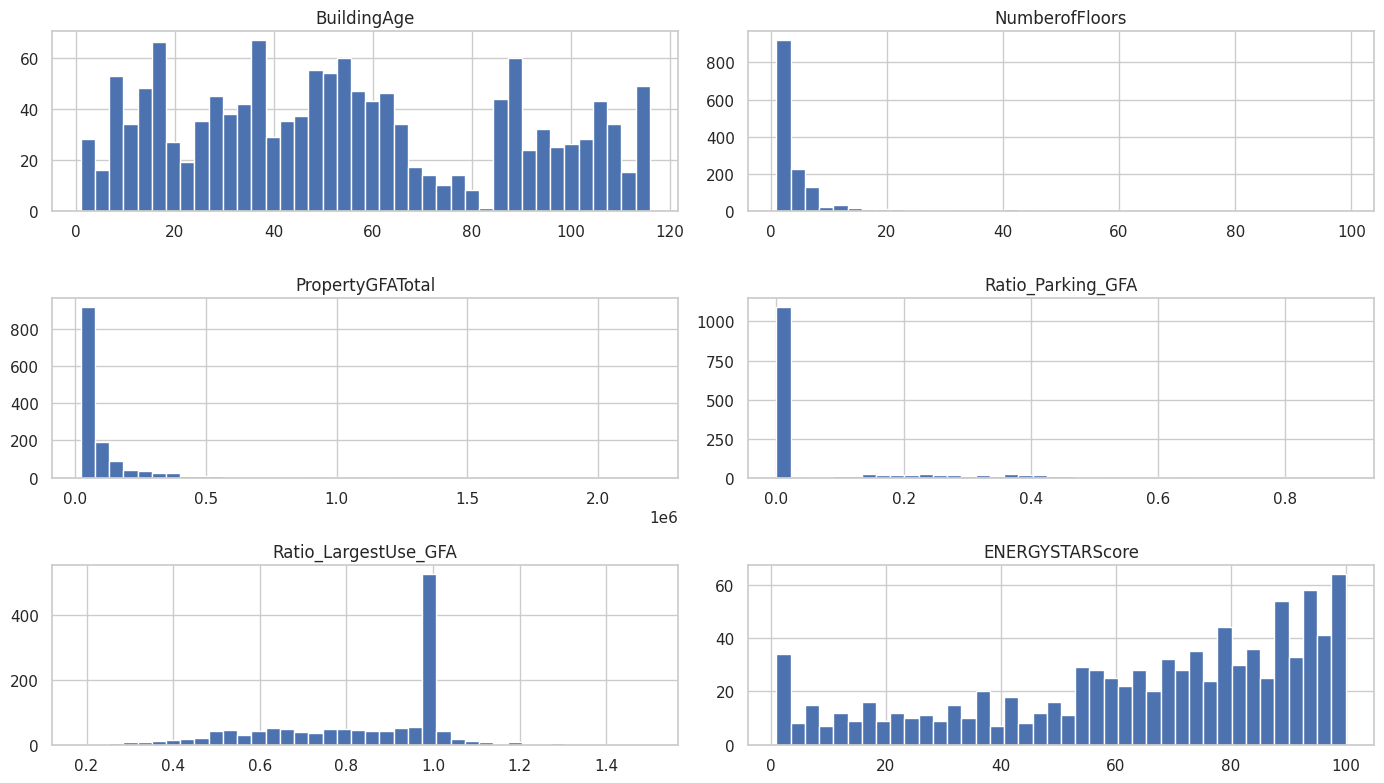

In [ ]:
num_cols = [
    "BuildingAge",
    "NumberofFloors",
    "PropertyGFATotal",
    "Ratio_Parking_GFA",
    "Ratio_LargestUse_GFA",
    "ENERGYSTARScore"
]

df_non_res[num_cols].hist(bins=40, figsize=(14,8))
plt.tight_layout()
plt.show()

<font size="4"><b>Interprétation des distributions des variables numériques principales</b></font>

Les histogrammes mettent en évidence des comportements distincts selon les variables :

- **`BuildingAge`**

  La distribution est relativement étalée, indiquant un parc immobilier hétérogène, avec des bâtiments allant de très récents à très anciens. Aucune concentration extrême n'apparaît, ce qui suggère une variable informative et bien répartie.

- **`NumberofFloors`**

  La distribution est fortement asymétrique à droite : la majorité des bâtiments possèdent peu d'étages, tandis qu'un nombre limité de bâtiments très hauts allonge la queue de distribution.

- **`PropertyGFATotal`**

  La surface totale présente une asymétrie marquée à droite. La plupart des bâtiments ont une surface modérée, mais quelques très grands bâtiments dominent l'échelle, ce qui est cohérent avec la diversité des usages non résidentiels.

- **`Ratio_Parking_GFA`**

  La majorité des bâtiments ont peu ou pas de surface dédiée au parking, tandis que certains présentent des ratios plus élevés. Cette variable est très concentrée près de 0, avec quelques cas spécifiques plus extrêmes.

- **`Ratio_LargestUse_GFA`**

  La distribution est fortement concentrée autour de 1, indiquant que, pour la majorité des bâtiments, l'usage principal occupe l'essentiel de la surface. Cela confirme la pertinence de se concentrer sur les usages dominants.

- **`ENERGYSTARScore`**

  La distribution est relativement étalée sur l'intervalle [1-100], avec une concentration plus forte sur les valeurs élevées, traduisant une grande diversité de performances énergétiques parmi les bâtiments.
<br>

**Synthèse**

Globalement, les variables numériques présentent des distributions **asymétriques mais cohérentes**, sans anomalies flagrantes. Ces profils confirment la nécessité :
- de recourir à des modèles capables de gérer des distributions non normales,
- et d'avoir déjà introduit des ratios et variables dérivées pour limiter l'effet des grandes échelles.
___

<font size="4"><b>Étape 2 - Corrélations avec les cibles</b></font>

On calcule les corrélations entre les variables numériques et les deux cibles :
- `SiteEnergyUse(kBtu)`
- `TotalGHGEmissions`

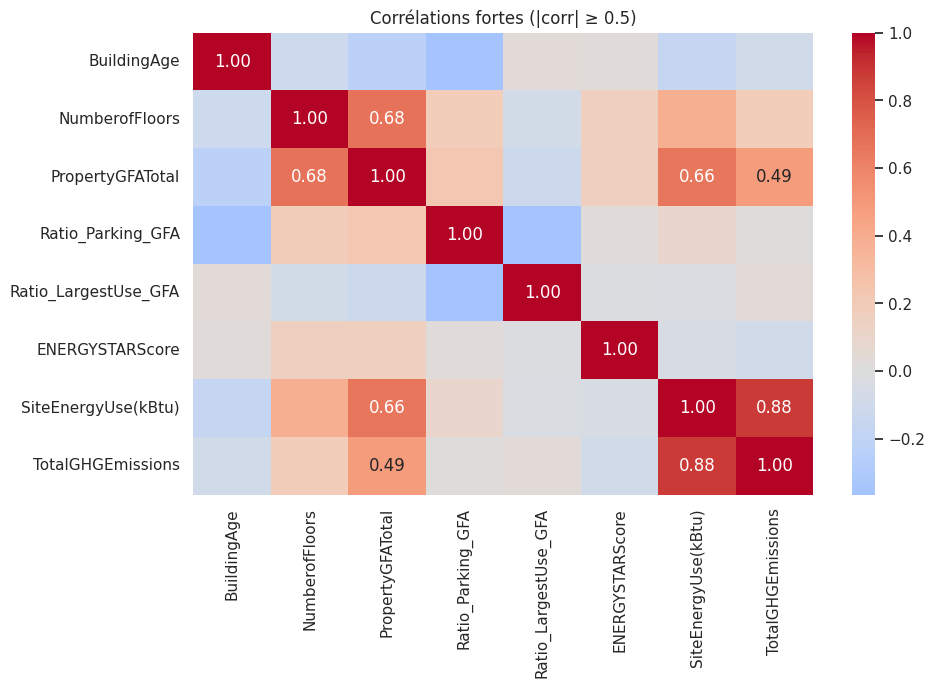

In [ ]:
corr_cols = num_cols + ["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]
corr_matrix = df_non_res[corr_cols].corr()

# Création d'une matrice d'annotations (strings)
annot = corr_matrix.copy().astype(object)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        value = corr_matrix.iloc[i, j]
        if abs(value) >= 0.4:
            annot.iloc[i, j] = f"{value:.2f}"
        else:
            annot.iloc[i, j] = ""

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=annot,
    fmt=""
)
plt.title("Corrélations fortes (|corr| ≥ 0.5)")
plt.show()

<font size="4"><b>Interprétation de la heatmap des corrélations</b></font>

La heatmap met en évidence plusieurs relations entre les variables numériques et les cibles.

- **Relation entre les deux cibles**

  La corrélation élevée entre **`SiteEnergyUse(kBtu)`** et **`TotalGHGEmissions`** (**0.88**) est attendue : une consommation énergétique plus élevée entraîne mécaniquement davantage d'émissions de gaz à effet de serre.

- **Rôle central de la surface totale**

  **`PropertyGFATotal`** est fortement corrélée au nombre d'étages (0.68) ainsi qu'aux deux cibles :
  - 0.66 avec la consommation énergétique,
  - 0.49 avec les émissions.
  
  Cela confirme que la taille du bâtiment est un facteur majeur expliquant les niveaux de consommation et d'émissions.

- **Effet modéré de la verticalité**

  **`NumberofFloors`** présente une corrélation positive avec les cibles, mais plus faible que celle de la surface totale, suggérant un effet indirect via la taille globale du bâtiment.

- **Ratios de surface et score énergétique**
  
  Les ratios de surface (**`Ratio_Parking_GFA`**, **`Ratio_LargestUse_GFA`**) et l'**`ENERGYSTARScore`** montrent des corrélations faibles à modérées avec les cibles, indiquant qu'ils apportent une information complémentaire plutôt qu'un facteur dominant.

- **Âge du bâtiment**

  **`BuildingAge`** apparaît peu corrélé aux autres variables et aux cibles, ce qui suggère un effet plus indirect ou dépendant d'autres facteurs (usage, rénovation, efficacité énergétique).
<br>

**Conclusion**

La heatmap confirme que :
- la **surface totale** est le principal facteur explicatif des consommations et émissions,
- les **ratios de surface** et le **score ENERGY STAR** apportent une information plus fine et potentiellement discriminante,
- aucune corrélation excessive n'indique, à ce stade, de redondance problématique entre les variables retenues.
___

<font size="4"><b>Étape 3 - Relations simples entre features clés et cibles</b></font>



L'objectif de cette étape est d'identifier visuellement et simplement :
- les **relations évidentes** entre certaines features clés et les cibles,
- les **tendances globales** (linéaires, non linéaires, dispersion),
- les variables qui semblent **informatives** pour la modélisation.
<br>

**Features clés à analyser :**

On se concentre volontairement sur quelques variables centrales :
- **`PropertyGFATotal`** → taille du bâtiment
- **`NumberofFloors`** → verticalité
- **`BuildingAge`** → ancienneté
- **`ENERGYSTARScore`** → performance énergétique
- **Ratios de surface** (ex : `Ratio_LargestUse_GFA`, `Ratio_Parking_GFA`)

Et les deux cibles :
- **`SiteEnergyUse(kBtu)`**
- **`TotalGHGEmissions`**
<br>

**Méthode : scatterplots simples**

On utilise des **nuages de points** avec transparence (`alpha`), pour visualiser la relation brute.

In [ ]:
def plot_scatter(feature_to_plot):
    targets = [
        "SiteEnergyUse(kBtu)",
        "TotalGHGEmissions"
    ]

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(targets),
        figsize=(12, 4),
        sharey=False
    )

    for j, target in enumerate(targets):
        ax = axes[j]

        # Filtrage spécifique à chaque cible pour l'affichage
        if target == "SiteEnergyUse(kBtu)":
            df_plot = df_non_res[df_non_res[target] <= 1.5e8]
        elif target == "TotalGHGEmissions":
            df_plot = df_non_res[df_non_res[target] <= 6000]

        sns.scatterplot(
            data=df_plot,
            x=feature_to_plot,
            y=target,
            alpha=0.5,
            ax=ax
        )

        ax.set_xlabel(feature_to_plot)
        ax.set_ylabel(target)
        ax.set_title(f"{feature_to_plot} vs {target}")

    plt.tight_layout()
    plt.show()

<font size="4"><b>Relations entre surface totale et cibles</b></font>

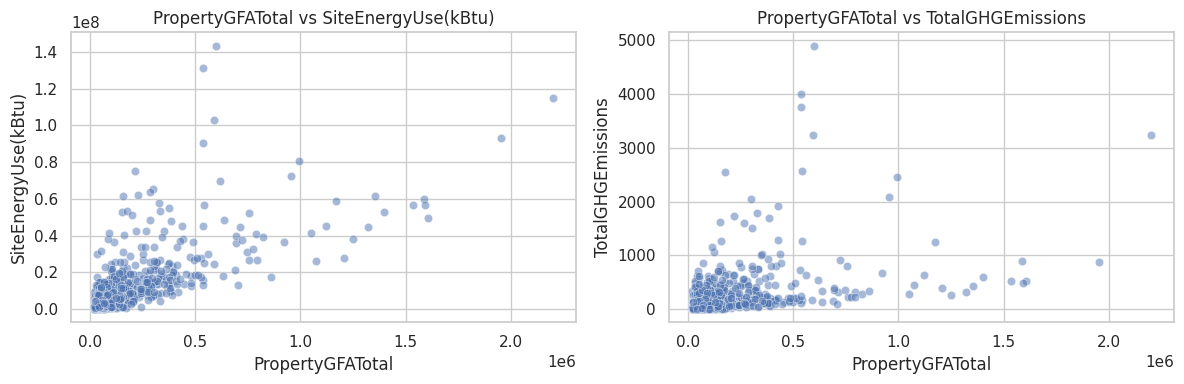

In [ ]:
plot_scatter("PropertyGFATotal")

Les deux scatterplots montrent une **relation globalement croissante** entre la surface totale des bâtiments (`PropertyGFATotal`) et les deux cibles (`SiteEnergyUse` et `TotalGHGEmissions`), ce qui est cohérent d'un point de vue métier : les bâtiments plus grands tendent à consommer plus d'énergie et à émettre davantage de gaz à effet de serre.

Cependant, cette relation reste **très dispersée**, notamment pour les grandes surfaces. À surface équivalente, on observe des niveaux de consommation et d'émissions très différents, ce qui suggère que la surface seule ne suffit pas à expliquer les cibles.

Enfin, la présence de quelques bâtiments très énergivores ou très émetteurs souligne l'importance d'intégrer d'autres variables explicatives (usage, efficacité énergétique, âge, ratios de surface, etc.) pour mieux capturer cette hétérogénéité.
___

<font size="4"><b>Relations entre nombre d'étages et cibles</b></font>

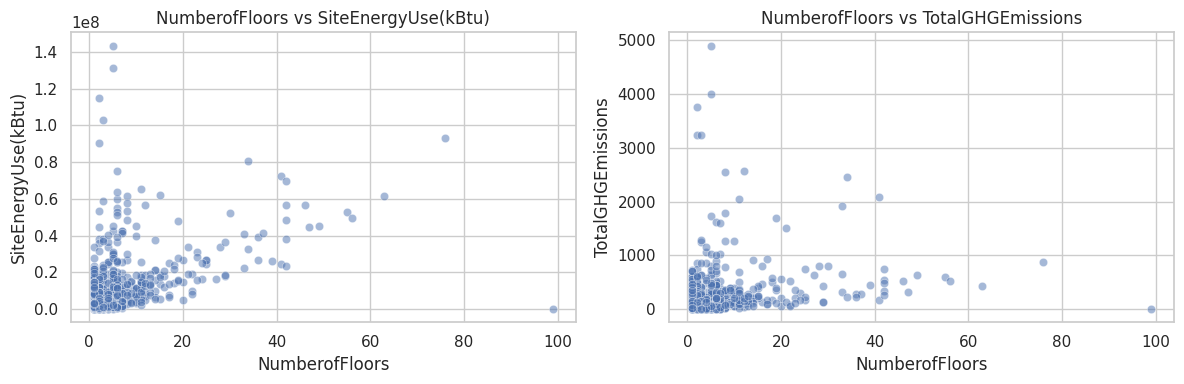

In [ ]:
plot_scatter("NumberofFloors")

- On observe une **tendance globale croissante** entre le nombre d'étages et la consommation d'énergie ainsi que les émissions.
- La **dispersion est importante**, en particulier pour les bâtiments de faible hauteur, ce qui indique que le nombre d'étages seul n'explique pas entièrement les niveaux de consommation ou d'émissions.
- Quelques bâtiments très hauts présentent des valeurs atypiques, sans constituer un comportement dominant.

→ Le nombre d'étages apparaît comme une **variable complémentaire**, informative mais secondaire par rapport à la surface totale du bâtiment.
___

<font size="4"><b>Relations entre âge du bâtiment et cibles</b></font>

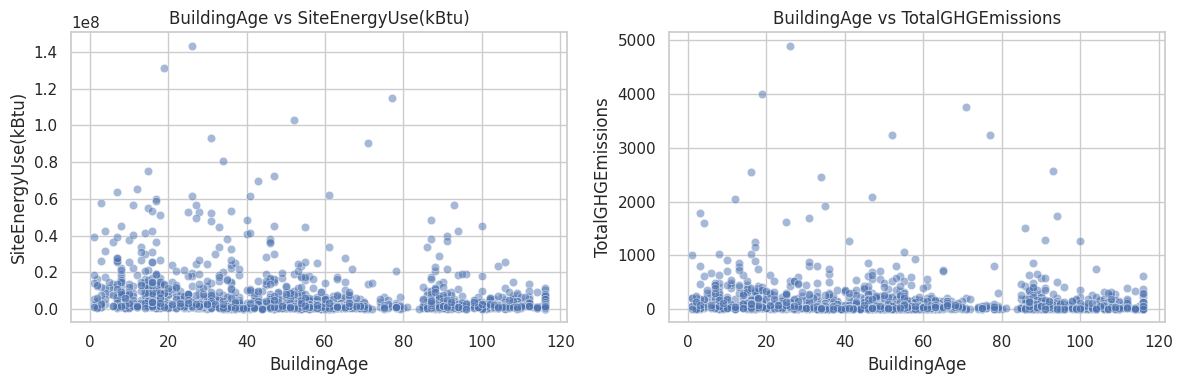

In [ ]:
plot_scatter("BuildingAge")

Aucune relation linéaire nette n'apparaît entre l'âge du bâtiment et les niveaux de consommation énergétique ou d'émissions de GES.
Les bâtiments anciens comme récents présentent des profils très variés, avec une forte dispersion des valeurs.

Cela suggère que l'**âge seul n'est pas un facteur explicatif suffisant**, mais qu'il peut néanmoins jouer un rôle indirect via d'autres variables (rénovations, usage, normes énergétiques), ce qui justifie son intégration comme feature complémentaire dans les modèles.
___

<font size="4"><b>Relations entre `ENERGYSTARScore` et cibles</b></font>

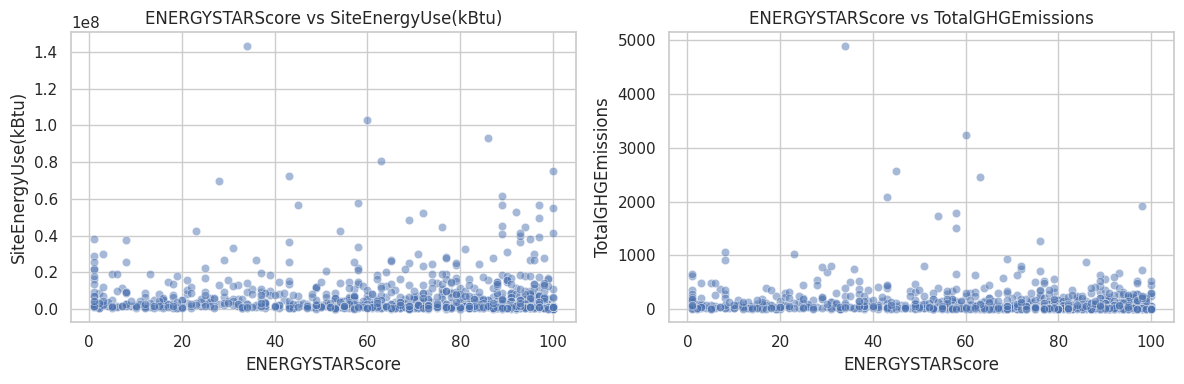

In [ ]:
plot_scatter("ENERGYSTARScore")

**Aucune relation monotone claire** n'apparaît entre l'`ENERGYSTARScore` et la consommation énergétique ou les émissions de GES.
La dispersion reste importante sur l'ensemble de l'intervalle de scores, y compris pour les bâtiments les mieux notés.

→ L'ENERGYSTARScore semble donc **apporter une information partielle**, utile pour capter certains comportements extrêmes, mais **insuffisante seule** pour expliquer les niveaux de consommation ou d'émissions. Son intérêt devra être évalué plus finement lors de la modélisation.
___

<font size="4"><b>Relations entre proportion de surface de l'usage principal et cibles</b></font>

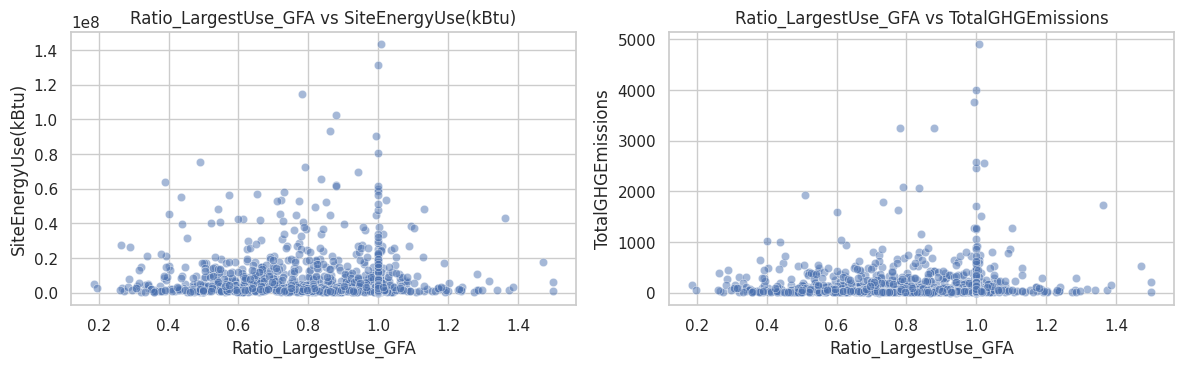

In [ ]:
plot_scatter("Ratio_LargestUse_GFA")

Le ratio de surface occupée par l'usage principal ne montre **pas de relation linéaire forte** avec la consommation énergétique ni avec les émissions de GES.
La majorité des bâtiments se concentrent autour d'un ratio élevé (proche de 1), indiquant un usage dominant, mais les niveaux de consommation et d'émissions restent très dispersés.

On observe néanmoins que certains bâtiments avec un usage principal très majoritaire peuvent présenter des valeurs élevées, ce qui suggère que **la nature de l'usage** est probablement plus déterminante que sa seule proportion de surface.

→ Cette variable apparaît donc comme **complémentaire**, utile pour enrichir la description du bâtiment, mais insuffisante seule pour expliquer les cibles.
___

<font size="4"><b>Relations entre proportion de surface dédiée au parking et cibles</b></font>

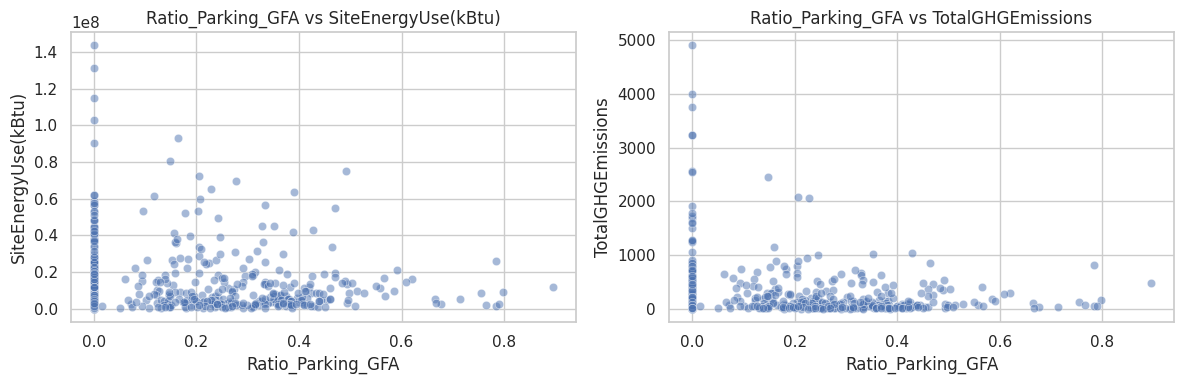

In [ ]:
plot_scatter("Ratio_Parking_GFA")

La proportion de surface dédiée au parking ne présente **pas de relation linéaire évidente** avec la consommation énergétique ni avec les émissions de GES.
La majorité des bâtiments ont un ratio de parking faible ou nul, avec une forte concentration des points près de zéro.

Quelques bâtiments avec une part importante de parking affichent des niveaux de consommation ou d'émissions variés, sans tendance claire, ce qui suggère que **la surface de parking seule n'est pas un facteur déterminant** des cibles.

→ Cette variable peut néanmoins apporter une information complémentaire sur la structure du bâtiment, mais son impact direct semble limité.
___
<br>

<font size="4"><b>Conclusion - Synthèse des relations et implications pour la modélisation</b></font>

<br>

L'analyse des distributions et des relations entre les variables explicatives et les cibles met en évidence les points suivants :

- **Surface totale du bâtiment et nombre d'étages**
  - Variables les plus fortement liées à la consommation énergétique et aux émissions de GES.
  - Relations positives mais très dispersées, montrant que la surface ou le nombre d'étages seuls sont insuffisants pour expliquer les cibles.

- **Âge du bâtiment**
  - L'âge du bâtiment apporte une information complémentaire.
  - Les relations observées sont faibles ou non linéaires, ce qui limite leur pouvoir explicatif pris isolément.

- **Ratios de surface**
  - Les ratios liés à l'usage principal et au parking enrichissent la description des bâtiments.
  - Ils ne présentent pas de relation directe forte avec les cibles, mais peuvent améliorer la modélisation en capturant des différences de structure et d'usage.

- **ENERGYSTARScore**
  - Aucune relation simple et monotone n'apparaît une fois les valeurs extrêmes écartées.
  - Cette variable conserve néanmoins un intérêt potentiel pour identifier certains comportements énergétiques atypiques.

→ Ces constats confirment la nécessité d'une approche **multivariée**, combinant plusieurs dimensions du bâtiment.

Le jeu de données est désormais suffisamment préparé pour passer à l'étape suivante : **le développement et la simulation d'un premier modèle de prédiction**.
___

# 2. Développement et simulation d'un premier modèle

## 2.0. Préparation des données pour la modélisation

Cette section marque le passage de l'analyse exploratoire à la modélisation. Son rôle est de constituer clairement :
- la matrice de features **X** (variables explicatives),
- la cible **y** (variable à prédire),

  et de vérifier rapidement que les dimensions obtenues sont cohérentes.

Pour cette étape 2, on choisit de se concentrer **uniquement sur la consommation énergétique** (`SiteEnergyUse(kBtu)`). Cela permet de mettre en place un premier pipeline de modélisation et une méthode d'évaluation robuste, avant d'appliquer le même processus à la seconde cible (`TotalGHGEmissions`) dans une étape ultérieure, une fois le feature engineering affiné et les premiers modèles stabilisés.

In [ ]:
TARGET = "SiteEnergyUse(kBtu)"

# Séparation features / cible
X = df_non_res.drop(columns=["SiteEnergyUse(kBtu)", "TotalGHGEmissions"])
y = df_non_res[TARGET]

# Vérification rapide
print("Cible :", TARGET)
print("X:", X.shape, "| y:", y.shape)

# Contrôle simple
X.head()

Cible : SiteEnergyUse(kBtu)
X: (1402, 102) | y: (1402,)


,OSEBuildingID,ZipCode,CouncilDistrictCode,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,MainUses_GFA_Ratio,Use_Adult Education,Use_Automobile Dealership,Use_Bank Branch,Use_Bar/Nightclub,Use_College/University,Use_Convenience Store without Gas Station,Use_Courthouse,Use_Data Center,Use_Distribution Center,Use_Enclosed Mall,Use_Fast Food Restaurant,Use_Financial Office,Use_Fire Station,Use_Fitness Center/Health Club/Gym,Use_Food Sales,Use_Food Service,Use_Hospital (General Medical & Surgical),Use_Hotel,Use_K-12 School,Use_Laboratory,Use_Library,Use_Lifestyle Center,Use_Manufacturing/Industrial Plant,Use_Medical Office,Use_Movie Theater,Use_Multifamily Housing,Use_Museum,Use_Non-Refrigerated Warehouse,Use_Office,Use_Other,Use_Other - Education,Use_Other - Entertainment/Public Assembly,Use_Other - Lodging/Residential,Use_Other - Mall,Use_Other - Public Services,...,Use_Other - Services,Use_Other - Technology/Science,Use_Other - Utility,Use_Other/Specialty Hospital,Use_Parking,Use_Performing Arts,"Use_Personal Services (Health/Beauty, Dry Cleaning, etc)",Use_Police Station,Use_Pre-school/Daycare,Use_Refrigerated Warehouse,"Use_Repair Services (Vehicle, Shoe, Locksmith, etc)",Use_Residence Hall/Dormitory,Use_Residential Care Facility,Use_Restaurant,Use_Retail Store,Use_Self-Storage Facility,Use_Senior Care Community,Use_Social/Meeting Hall,Use_Strip Mall,Use_Supermarket/Grocery Store,Use_Swimming Pool,Use_Urgent Care/Clinic/Other Outpatient,Use_Vocational School,Use_Worship Facility,BuildingAge,Ratio_Parking_GFA,Ratio_Building_GFA,Ratio_LargestUse_GFA,Ratio_SecondaryUses_GFA,BuildingType_NonResidential,BuildingType_Nonresidential COS,BuildingType_Nonresidential WA,BuildingType_SPS-District K-12,Neighborhood_Ballard,Neighborhood_CENTRAL,Neighborhood_Central,Neighborhood_DELRIDGE,Neighborhood_DOWNTOWN,Neighborhood_Delridge,Neighborhood_EAST,Neighborhood_GREATER DUWAMISH,Neighborhood_LAKE UNION,Neighborhood_MAGNOLIA / QUEEN ANNE,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_North,Neighborhood_Northwest,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST
0,1,"98,101.00",7,47.61,-122.34,1.00,12,88434,0,88434,"88,434.00",0.00,0.00,60.00,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,0.00,1.00,1.00,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2,"98,101.00",7,47.61,-122.33,1.00,11,103566,15064,88502,"83,880.00","15,064.00","4,622.00",61.00,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,20,0.15,0.85,0.81,0.19,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,3,"98,101.00",7,47.61,-122.34,1.00,41,956110,196718,759392,"756,493.00",0.00,0.00,43.00,0.79,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,47,0.21,0.79,0.79,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,5,"98,101.00",7,47.61,-122.34,1.00,10,61320,0,61320,"61,320.00",0.00,0.00,56.00,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,90,0.00,1.00,1.00,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,8,"98,121.00",7,47.61,-122.34,1.00,18,175580,62000,113580,"123,445.00","68,009.00",0.00,75.00,1.09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,36,0.35,0.65,0.70,0.39,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


`ENERGYSTARScore` est volontairement exclu des premières modélisations afin d'établir une baseline robuste fondée uniquement sur des caractéristiques structurelles et d'éviter toute hypothèse arbitraire liée à l'imputation du score. Son impact sera analysé ultérieurement de manière dédiée.

In [ ]:
# Exclusion temporaire de l'ENERGYSTARScore pour l'étape 2
X = X.drop(columns=["ENERGYSTARScore"], errors="ignore")

print("Features après exclusion ENERGYSTARScore :", X.shape[1])

Features après exclusion ENERGYSTARScore : 101


## 2.1. Séparation des données en jeux d'entraînement et de test

L'objectif de cette étape est de **séparer les données en deux sous-ensembles indépendants** afin d'évaluer correctement la capacité de généralisation des modèles.
Le jeu d'entraînement servira à ajuster les modèles, tandis que le jeu de test permettra d'évaluer leurs performances sur des données non vues, condition indispensable pour détecter un éventuel sur-apprentissage.

Une séparation classique **train / test** est utilisée ici, avant la mise en place plus poussée de la validation croisée dans les étapes suivantes.

In [ ]:
# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Vérification des dimensions
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1121, 101)
X_test  : (281, 101)
y_train : (1121,)
y_test  : (281,)


Cette séparation constitue la base minimale pour comparer les performances des modèles simples (baseline) et des modèles plus robustes qui seront testés par la suite.

## 2.2. Modèle de référence (baseline) : *Dummy Regressor*

Avant d'évaluer des modèles plus sophistiqués, il est essentiel de **définir une ligne de base**.

Le rôle de ce modèle *dummy* est simple : fournir une performance minimale de référence, sans exploiter réellement les features (par exemple en prédisant systématiquement la moyenne de la cible).

Tout modèle plus complexe devra **faire mieux que ce baseline** pour être considéré comme pertinent.

In [ ]:
# Modèle baseline : prédiction de la moyenne
dummy_model = DummyRegressor(strategy="mean")

# Entraînement
dummy_model.fit(X_train, y_train)

# Prédictions
y_pred_dummy = dummy_model.predict(X_test)

## 2.3. Modèles simples mais robustes : Ridge et Lasso

Après avoir défini une baseline naïve, cette étape introduit des **modèles linéaires régularisés**.

L'objectif est de conserver la simplicité et l'interprétabilité d'une régression linéaire, tout en limitant le sur-apprentissage et en gérant la redondance entre les variables explicatives.
- **Ridge** applique une pénalisation de type L2, qui réduit l'amplitude des coefficients sans en annuler.
- **Lasso** applique une pénalisation de type L1, qui peut annuler certains coefficients et ainsi effectuer une première forme de sélection de variables.

Étant sensibles à l'échelle des variables, ces modèles sont intégrés dans des **pipelines incluant une normalisation**.

In [ ]:
# Pipeline Ridge
ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

# Pipeline Lasso
lasso_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.001, random_state=42, max_iter=200000, tol=1e-3, selection="random"))
])

Ces deux modèles constituent une **première famille de modèles exploitant réellement les features** et serviront de base de comparaison lors de l'évaluation rigoureuse par validation croisée à l'étape suivante.

<br>
<font size="4"><b>Initialisation de la valeur de alpha</b></font>

Pour les méthodes Ridge et Lasso, on doit choisir leurs intensités de régularisation ou valeur de `alpha`. Dans notre cas, on a :
- beaucoup de variables encodées (OneHot, usages, quartiers),
- des corrélations fortes (surfaces, ratios),
- des features à échelles très différentes (avant scaling).

Donc :
- **Ridge** → robuste avec `alpha≈1`
- **Lasso** → nécessite un alpha petit pour ne pas tout supprimer

Ces valeurs permettent de :
- vérifier que le pipeline est sain,
- comparer Dummy / Ridge / Lasso,
- préparer proprement l'étape suivante.

## 2.4. Évaluation rigoureuse des modèles par validation croisée (R², MAE, RMSE)

L'objectif de cette étape est d'évaluer les performances des modèles de manière robuste, en évitant de tirer des conclusions sur un seul split.

On utilise donc une **validation croisée (K-Fold)** sur le jeu d'entraînement. Cela permet d'obtenir une estimation plus stable des performances sur des données non vues.

Conformément aux consignes, l'évaluation repose sur plusieurs métriques adaptées à une régression :
- **R²** : qualité d'ajustement globale,
- **MAE** : erreur moyenne en valeur absolue (interprétable),
- **RMSE** : pénalise davantage les grosses erreurs.

Enfin, on compare ces résultats de validation croisée à une évaluation simple sur le jeu de test, afin d'avoir un point de contrôle "en conditions réelles".

In [ ]:
models = {
    "Dummy(mean)": dummy_model,
    "Ridge (imputer+scaler)": ridge_model,
    "Lasso (imputer+scaler)": lasso_model
}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )

    rmse_test = np.sqrt(-scores["test_mse"])
    rmse_train = np.sqrt(-scores["train_mse"])

    cv_results.append({
        "Model": name,
        "R2_train_mean": np.mean(scores["train_r2"]),
        "R2_test_mean": np.mean(scores["test_r2"]),
        "MAE_train_mean": -np.mean(scores["train_mae"]),
        "MAE_test_mean": -np.mean(scores["test_mae"]),
        "RMSE_train_mean": np.mean(rmse_train),
        "RMSE_test_mean": np.mean(rmse_test)
    })

results_cv = pd.DataFrame(cv_results).sort_values("RMSE_test_mean")
results_cv

,Model,R2_train_mean,R2_test_mean,MAE_train_mean,MAE_test_mean,RMSE_train_mean,RMSE_test_mean
1,Ridge (imputer+scaler),0.77,0.45,"4,119,512.08","4,928,216.85","9,838,994.37","12,081,862.58"
2,Lasso (imputer+scaler),0.77,0.45,"4,132,226.74","4,942,182.06","9,837,620.00","12,084,925.24"
0,Dummy(mean),0.00,-0.01,"8,483,237.33","8,490,673.65","20,296,182.91","18,926,673.55"


<font size="4"><b>Interprétation des performances des modèles</b></font>

- **Le modèle Dummy** sert de référence minimale :
  - Il ne capture aucune structure des données (R² = 0 ou négatif).
  - Les erreurs MAE et RMSE sont très élevées, ce qui confirme qu'une prédiction constante est insuffisante pour ce problème.

- **Les modèles Ridge et Lasso** améliorent nettement les performances :
  - Les R² en entraînement sont élevés (~0.77), montrant une bonne capacité d'ajustement.
  - Les R² en validation croisée sont plus faibles (~0.45), ce qui indique une perte de performance sur données non vues mais reste significativement meilleure que le dummy.
  - Les erreurs MAE et RMSE sont réduites d'environ 40-45 % par rapport au modèle de référence.

- **Comparaison Ridge vs Lasso** :
  - Les performances sont très proches sur l'ensemble des métriques.
  - Ridge présente une stabilité légèrement meilleure (RMSE test marginalement plus faible).
  - Lasso n'apporte pas de gain significatif à ce stade, malgré une complexité supplémentaire liée à la sélection de variables.

Ces résultats suggèrent que **la relation entre les variables explicatives et la consommation énergétique est partiellement capturée**, mais qu'une part importante de la variabilité reste inexpliquée.

Ils constituent néanmoins une **baseline solide** sur laquelle s'appuieront les étapes suivantes de feature engineering et de modélisation plus avancée.
___

## 2.5. Conclusion - Choix du modèle de référence et limites identifiées

À l'issue de cette première phase de modélisation, les modèles linéaires régularisés (Ridge et Lasso) montrent une amélioration nette des performances par rapport au modèle de référence naïf. Ils parviennent à capter une partie significative de la relation entre les caractéristiques des bâtiments et leur consommation énergétique.

<br>
<font size="4"><b>Choix du modèle de référence</b></font>

Le **modèle Ridge** est retenu comme **modèle de référence** pour la suite du projet :
- Il présente des performances très légèrement supérieures à celles du Lasso sur l'ensemble des métriques évaluées (R², MAE, RMSE).
- Il offre une meilleure stabilité et ne nécessite pas d'ajustements spécifiques pour assurer la convergence.
- À complexité équivalente, le Lasso n'apporte pas de gain significatif et requiert un réglage plus fin de ses hyperparamètres.

Ce choix permet de conserver un modèle **simple, robuste et interprétable**, adapté à une phase de modélisation exploratoire.

<br>
<font size="4"><b>Limites du premier modèle</b></font>

L'analyse des résultats met néanmoins en évidence plusieurs limites :
- L'écart entre les performances en entraînement et en validation croisée suggère une **capacité de généralisation encore limitée**.
- Une part importante de la variabilité de la consommation énergétique reste inexpliquée, ce qui indique que les relations entre features et cible sont **non linéaires ou incomplètement capturées**.
- Les variables utilisées décrivent principalement la structure des bâtiments, sans intégrer finement certains aspects d'usage ou de comportement énergétique.

<br>
<font size="4"><b>Pistes d'amélioration pour la suite</b></font>

Ces constats ouvrent la voie à l'étape suivante :
- enrichir le **feature engineering** (nouvelles transformations, interactions, ratios plus fins),
- tester des **modèles plus expressifs**, capables de capturer des relations non linéaires,
- réévaluer l'intérêt de certaines variables écartées ou traitées séparément, comme l'**ENERGYSTARScore**.

→ Cette étape 2 permet ainsi de poser une base solide, de comprendre les limites du premier modèle et de définir clairement les leviers d'amélioration à explorer à l'étape 3.

# 3. Amélioration du feature engineering

## 3.0. Introduction

À l'issue de l'étape 2, un **modèle Ridge** a été retenu comme modèle de référence pour la prédiction de la consommation énergétique des bâtiments non résidentiels. Ce modèle présente de meilleures performances que le modèle naïf, tout en restant simple, stable et interprétable.

Cependant, les résultats obtenus montrent que :
- une part importante de la variance reste inexpliquée ;
- les prédictions sont fortement influencées par les variables de surface ;
- certaines relations potentiellement non linéaires entre les caractéristiques des bâtiments et la consommation énergétique ne sont pas encore pleinement captées.

Cette étape vise donc à **améliorer le feature engineering**, en testant de nouvelles transformations et représentations des données afin d'augmenter la capacité prédictive du modèle, tout en conservant une approche maîtrisée et interprétable.

## 3.1. Analyse rapide des limites du modèle actuel

Le modèle Ridge retenu à l'étape précédente constitue une base solide, mais ses performances montrent encore des marges d'amélioration.

Sur les données de test, le modèle atteint un **R² d'environ 0,45**, indiquant qu'une part importante de la variabilité de la consommation énergétique reste inexpliquée. Les erreurs absolues et quadratiques (MAE et RMSE) restent élevées, ce qui traduit des **écarts significatifs entre les prédictions et les valeurs réelles**, notamment pour les bâtiments les plus énergivores.

Par ailleurs, l'analyse exploratoire suggère que le modèle est **fortement piloté par les variables de surface**, ce qui peut masquer d'autres effets structurels ou fonctionnels des bâtiments. Enfin, l'approche linéaire du Ridge limite la capacité du modèle à capturer des **relations non linéaires** ou des interactions entre variables.

Ces constats justifient la poursuite du travail de **feature engineering**, afin d'enrichir l'information fournie au modèle et d'améliorer sa capacité de généralisation.

## 3.2. Nouvelles hypothèses de feature engineering

À partir des limites observées sur le modèle de référence, plusieurs hypothèses peuvent être formulées pour améliorer la qualité des prédictions :

- **La relation entre la surface des bâtiments et la consommation énergétique n'est pas strictement linéaire**. Une transformation ou une re-représentation de ces variables pourrait mieux capturer cette relation.

- **Certaines variables de surface ou de structure sont fortement corrélées entre elles**, ce qui peut nuire à la stabilité et à l'interprétation du modèle, même avec une régularisation de type Ridge.

- **Certaines variables issues de l'encodage ou du feature engineering initial peuvent être peu informatives ou redondantes**, et pourraient être filtrées ou combinées.

Ces hypothèses guideront les transformations et sélections de variables testées dans les sections suivantes.

## 3.3. Tests ciblés de feature engineering

### 3.3.1. Transformation non linéaire des surfaces

L'analyse exploratoire a montré que les variables de surface (ex. `PropertyGFATotal`) sont fortement liées à la consommation énergétique, mais cette relation est souvent non linéaire : quelques très grands bâtiments peuvent tirer la distribution et la relation globale.

L'objectif ici est donc de tester une transformation simple (logarithme) sur les surfaces afin de réduire l'effet des valeurs extrêmes et de faciliter l'apprentissage d'un modèle linéaire.

#### 3.3.1.1. Création de features log-transformées (surfaces)

In [ ]:
# Copie de travail pour tester les transformations
X_log = X_train.copy()

# Colonnes de surface candidates
surface_cols = [
    col for col in df_non_res.columns
    if "GFA" in col and "Ratio" not in col
]

# Création des versions log1p (log(1+x)) et suppression des surfaces brutes
for col in surface_cols:
    if col in X_log.columns:
        X_log[f"log1p_{col}"] = np.log1p(X_log[col])
        X_log = X_log.drop(columns=col, errors="ignore")


#### 3.3.1.2. Comparaison rapide : Ridge avec surfaces brutes vs surfaces log

On compare deux variantes :
- **Baseline :** Ridge sur les surfaces "brutes"
- **Test :** Ridge sur les surfaces log-transformées (en remplaçant les colonnes originales)

In [ ]:
target = "SiteEnergyUse(kBtu)"

ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

# Variante A : surfaces brutes
scores_base = cross_validate(
    ridge_pipe, X_train, y_train,
    cv=5, scoring=scoring, return_train_score=True
)

rmse_base = np.sqrt(-scores_base["test_mse"])

# Variante B : surfaces log
scores_log = cross_validate(
    ridge_pipe, X_log, y_train,
    cv=5, scoring=scoring, return_train_score=True
)

rmse_log = np.sqrt(-scores_log["test_mse"])

# Visualisation des scores
results_331 = pd.DataFrame([
    {
        "Variant": "Ridge - surfaces brutes",
        "R2_test_mean": np.mean(scores_base["test_r2"]),
        "MAE_test_mean": -np.mean(scores_base["test_mae"]),
        "RMSE_test_mean": np.mean(rmse_base),
    },
    {
        "Variant": "Ridge - surfaces log1p",
        "R2_test_mean": np.mean(scores_log["test_r2"]),
        "MAE_test_mean": -np.mean(scores_log["test_mae"]),
        "RMSE_test_mean": np.mean(rmse_log),
    }
]).sort_values("RMSE_test_mean")

results_331

,Variant,R2_test_mean,MAE_test_mean,RMSE_test_mean
0,Ridge - surfaces brutes,0.45,"4,928,216.85","12,081,862.58"
1,Ridge - surfaces log1p,0.12,"6,008,111.32","14,267,339.85"


#### 3.3.1.3. Décision

Les performances des deux variantes sont les suivantes :
- **Surfaces brutes**
  - R² test ≈ **0.45**
  - MAE test ≈ **4.93 M kBtu**
  - RMSE test ≈ **12.08 M kBtu**

- **Surfaces transformées**
  - R² test ≈ **0.12**
  - MAE test ≈ **6.01 M kBtu**
  - RMSE test ≈ **14.27 M kBtu**

La transformation logarithmique des surfaces entraîne une **dégradation nette des performances**, avec :
- une forte baisse du R², indiquant une perte importante de capacité explicative ;
- une augmentation marquée des erreurs absolues et quadratiques (MAE et RMSE).

Dans ce contexte, la relation entre les surfaces et la consommation énergétique semble **mieux captée sous forme linéaire** par le modèle Ridge.

→ **Décision** :

Les variables de surface seront **conservées sous leur forme brute** pour la suite de la modélisation.  
La transformation logarithmique des surfaces est **abandonnée**, car elle détériore significativement les performances du modèle.
___

### 3.3.2. Réduction de la redondance entre variables

Certaines variables décrivent des dimensions proches du bâtiment (surfaces totales, surfaces par usage, ratios).
Même si Ridge limite les effets de multicolinéarité, des variables fortement corrélées peuvent :
- dégrader la stabilité des coefficients,
- rendre le modèle plus difficile à interpréter,
- ajouter du bruit inutile.

L'objectif ici est de tester si un **sous-ensemble plus compact** de variables permet de conserver (ou améliorer) les performances.

#### 3.3.2.1. Identification des groupes corrélés

On se concentre sur les variables liées aux surfaces et aux ratios.

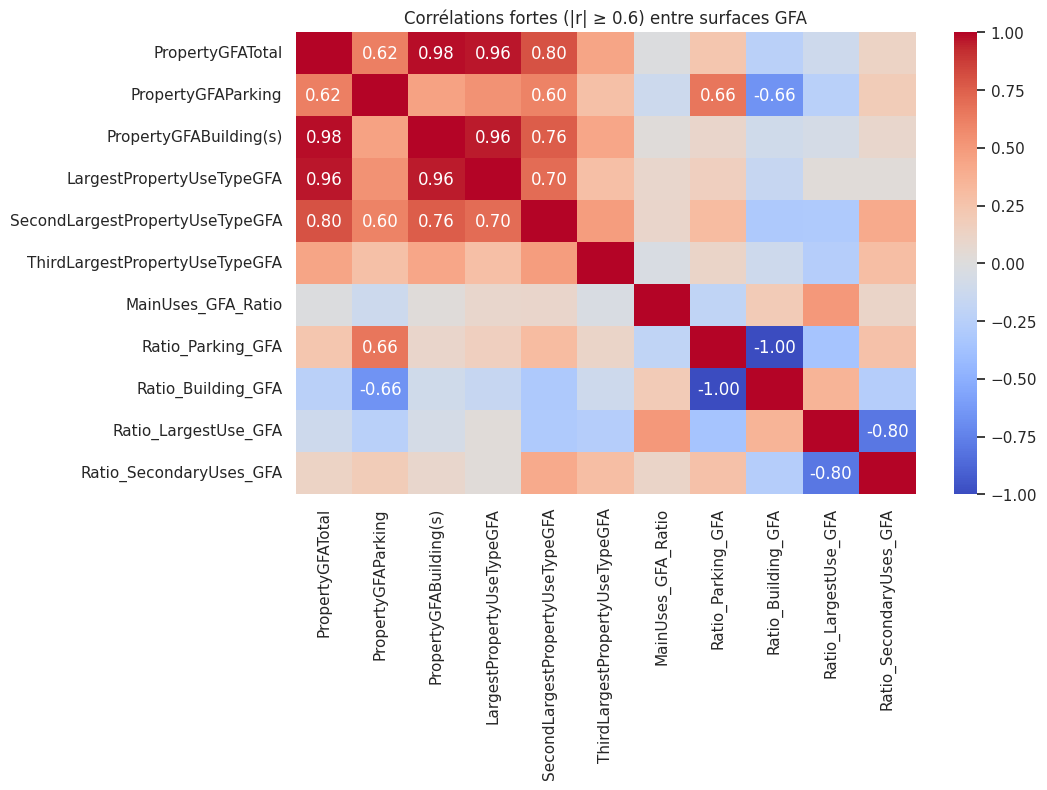

In [ ]:
surface_and_ratio_cols = [
    col for col in df_non_res.columns
    if "GFA" in col
]

corr_subset = df_non_res[surface_and_ratio_cols].corr()

# Création d'une matrice d'annotations vide (chaînes)
annot = corr_subset.copy().astype(str)

threshold = 0.6

for i in range(corr_subset.shape[0]):
    for j in range(corr_subset.shape[1]):
        val = corr_subset.iloc[i, j]
        if abs(val) >= threshold and i != j:
            annot.iloc[i, j] = f"{val:.2f}"
        else:
            annot.iloc[i, j] = ""

plt.figure(figsize=(10,6))
sns.heatmap(
    corr_subset,
    cmap="coolwarm",
    center=0,
    annot=annot,
    fmt="",
    cbar=True
)
plt.title("Corrélations fortes (|r| ≥ 0.6) entre surfaces GFA")
plt.show()

<font size="4"><b>Interprétation des groupes de variables corrélées</b></font>

L'analyse des corrélations met en évidence plusieurs blocs fortement redondants :

<br>

**1) Bloc "taille globale du bâtiment"**

Les variables suivantes sont **très fortement corrélées entre elles** :
- `PropertyGFATotal`
- `PropertyGFABuilding(s)`
- `LargestPropertyUseTypeGFA`

(corrélations ≈ **0.96-0.98**)

→ Elles décrivent toutes **la même information principale : la taille du bâtiment**. Garder ces trois variables est redondant.

<br>

**2) Bloc "structure interne des usages"**

- `SecondLargestPropertyUseTypeGFA`
- `LargestPropertyUseTypeGFA`

sont **fortement corrélées** à la surface totale (**0.70**), mais apportent une **décomposition interne** de la surface.

→ Ces variables sont utiles pour décrire la structure, mais pas indépendantes.

<br>

**3) Bloc "parking vs bâtiment"**

- `Ratio_Parking_GFA` et `Ratio_Building_GFA` sont **parfaitement opposés** (**corr = -1.00**)

C'est logique :

>si la part du parking augmente, la part du bâtiment diminue.

→ Ces deux variables portent **exactement la même information** : une seule suffit.

<br>

**4) Bloc "répartition des usages"**

- `Ratio_LargestUse_GFA`
- `Ratio_SecondaryUses_GFA`

sont fortement anticorrélées (**-0.80**)

→ Elles décrivent deux façons opposées de représenter **la concentration des usages**. Les garder toutes les deux est redondant.

___

<font size="4"><b>Conclusion</b></font>

Les surfaces absolues (GFA) et les ratios décrivent **les mêmes phénomènes sous deux formes différentes** :
- les GFA décrivent la **taille**
- les ratios décrivent la **structure**

Cela confirme que le dataset contient une **forte redondance**, ce qui justifie de tester un modèle avec :

> **une surface globale** + **des ratios de structure**, plutôt que toutes les surfaces détaillées.

C'est ce qui sera évalué dans la section suivante.

#### 3.3.2.2. Création d'un jeu de variables réduit

La matrice de corrélation montre clairement que :

- PropertyGFATotal, PropertyGFABuilding(s) et LargestPropertyUseTypeGFA sont quasi équivalents (corr ≈ 0.96-0.98)  
  → une seule de ces variables suffit pour représenter la taille globale.

- Les ratios (Ratio_*) décrivent la structure interne du bâtiment (répartition des surfaces) de façon indépendante de la taille.

- Certains ratios sont parfaitement redondants :
  - Ratio_Parking_GFA et Ratio_Building_GFA (corr = -1)
  - Ratio_LargestUse_GFA et Ratio_SecondaryUses_GFA (corr ≈ -0.80)

→ On construit donc un jeu minimaliste mais informatif :
- 1 variable de taille
- quelques ratios de structure
- toutes les autres variables non liées aux GFA

<br>

<font size="4"><b>Variables retenues pour représenter la surface</b></font>

- `PropertyGFATotal` : Taille globale
- `Ratio_Parking_GFA` : Part du parking
- `Ratio_LargestUse_GFA` : Concentration de l'usage principal
- `Ratio_SecondaryUses_GFA` : Diversité des usages secondaires

In [ ]:
target = "SiteEnergyUse(kBtu)"

# Variables représentant la structure du bâtiment
surface_features_reduced = [
    "PropertyGFATotal",
    "Ratio_Parking_GFA",
    "Ratio_LargestUse_GFA",
    "Ratio_SecondaryUses_GFA"
]

# Toutes les autres variables non liées aux surfaces
other_features = [
    col for col in X_train.columns
    if (
        "GFA" not in col
        and "Ratio" not in col
    )
]

X_reduced = X_train[other_features + surface_features_reduced]

print("Nombre de variables (jeu complet) :", X_train.shape[1])
print("Nombre de variables (jeu réduit) :", X_reduced.shape[1])

Nombre de variables (jeu complet) : 101
Nombre de variables (jeu réduit) : 94


#### 3.3.2.3. Test du modèle Ridge avec variables réduites

In [ ]:
ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

scores_reduced = cross_validate(
    ridge_pipe,
    X_reduced,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=True
)

rmse_reduced = np.sqrt(-scores_reduced["test_mse"])

results_332 = pd.DataFrame([
    {
        "Variant": "Ridge - surfaces brutes",
        "R2_test_mean": np.mean(scores_base["test_r2"]),
        "MAE_test_mean": -np.mean(scores_base["test_mae"]),
        "RMSE_test_mean": np.mean(rmse_base),
    },
    {
        "Variant": "Ridge - variables réduites",
        "R2_test_mean": np.mean(scores_reduced["test_r2"]),
        "MAE_test_mean": -np.mean(scores_reduced["test_mae"]),
        "RMSE_test_mean": np.mean(rmse_reduced)
    }
]).sort_values("RMSE_test_mean")

results_332

,Variant,R2_test_mean,MAE_test_mean,RMSE_test_mean
0,Ridge - surfaces brutes,0.45,"4,928,216.85","12,081,862.58"
1,Ridge - variables réduites,0.36,"5,100,614.10","12,663,183.07"


#### 3.3.2.4. Décision

Les performances des deux variantes sont les suivantes :
- **Surfaces brutes**
  - R² test ≈ **0.45**
  - MAE test ≈ **4.93 M kBtu**
  - RMSE test ≈ **12.08 M kBtu**

- **variables réduites**
  - R² test ≈ **0.36**
  - MAE test ≈ **5.10 M kBtu**
  - RMSE test ≈ **12.66 M kBtu**

<br>

→ **Interprétation**

Le modèle basé sur le jeu de **variables réduit** présente des performances **inférieures** à celles du modèle utilisant les surfaces brutes :
- le R² diminue, indiquant une perte de capacité explicative ;
- les erreurs MAE et RMSE augmentent, traduisant une dégradation globale de la précision.

Cela suggère que, dans ce cadre linéaire (Ridge), les variables de surface détaillées apportent encore une **information utile** que les seuls ratios ne parviennent pas à compenser.

<br>

→ **Décision**

À ce stade, **le jeu de variables réduit n'est pas retenu comme version finale** pour le modèle Ridge.

Les surfaces détaillées et les ratios seront **conservés temporairement** afin :
- de ne pas pénaliser les performances,
- et de laisser aux modèles non linéaires testés ultérieurement (Random Forest, Gradient Boosting, SVM) la possibilité d'exploiter ces relations plus complexes.

La réduction définitive des variables sera réévaluée après les tests de modèles plus avancés.

### 3.3.3. Test de réduction de dimension par PCA

<font size="4"><b>Hypothèse</b></font>

> La forte corrélation entre certaines variables (surfaces, usages, ratios) suggère que l'information pourrait être représentée dans un espace de plus faible dimension, ce qui pourrait améliorer la performance et la stabilité du modèle.

#### 3.3.3.1 Préparation des données pour la PCA

La PCA nécessite des données :
- **numériques uniquement**
- **standardisées**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

X_scaled.shape

(1121, 101)

#### 3.3.3.2 Variance expliquée par les composantes principales

On cherche à savoir **combien de composantes sont nécessaires** pour conserver l'information.

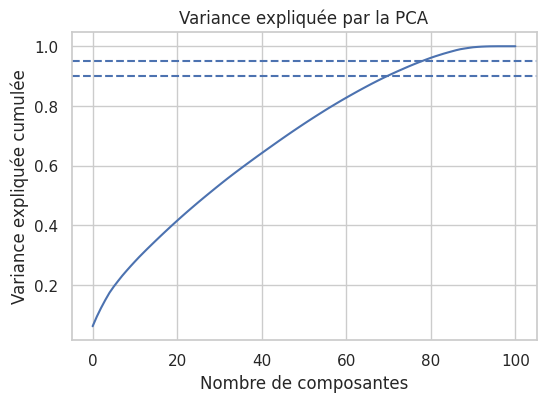

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(6,4))
plt.plot(explained_variance)
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée par la PCA")
plt.show()

Le graphique et la série de valeurs montrent que **la variance est très progressivement expliquée** par la PCA : aucune composante ne domine fortement.

Concrètement :
- Les **10 premières composantes** n'expliquent qu'environ **26 %** de l'information.
- Il faut environ **55 composantes** pour atteindre **~80 %**.
- Il faut près de **70 composantes** pour atteindre **90 %**.
- Et environ **80 composantes** pour dépasser **95 %**.

→ Cela indique que le jeu de variables est **peu redondant** : l'information est répartie sur beaucoup de dimensions.

La PCA ne permet donc **pas de forte compression** sans perte d'information importante, ce qui suggère que **garder les variables originales** est préférable, surtout pour des modèles interprétables et des méthodes non linéaires à venir.

#### 3.3.3.3. Décision

Les résultats de l'analyse par PCA montrent qu'un nombre élevé de composantes est nécessaire pour conserver une part significative de l'information initiale (environ 70 composantes pour atteindre 90 % de variance expliquée). La réduction de dimension reste donc limitée et ne permet pas de simplifier réellement l'espace des features.

Dans ce contexte, poursuivre avec un modèle **Ridge combiné à une PCA** n'apporterait pas de gain attendu :
- Ridge est déjà capable de gérer efficacement la colinéarité entre variables,
- la PCA n'introduit aucune non-linéarité supplémentaire,
- l'interprétabilité des variables serait fortement dégradée.

De plus, réduire artificiellement la dimension du jeu de données risquerait d'éliminer des informations utiles à des modèles plus avancés et non linéaires (arbres, ensembles, boosting), qui exploitent mieux les interactions complexes entre variables.

→ **Décision :**

- Ne pas poursuivre les tests Ridge + PCA
- Conserver l'ensemble des features construites et nettoyées
- Réserver l'exploitation de ces variables à des modèles plus expressifs lors des étapes suivantes

Cette décision permet de maintenir un bon compromis entre **performance, explicabilité et flexibilité** pour la suite du projet.

## 3.4. Sélection finale des features et préparation de l'étape 4

### 3.4.1. Décision finale sur les transformations et les variables retenues

<font size="4"><b>Bilan des tests de feature engineering</b></font>

Les tests réalisés à l'étape 3 visaient à vérifier si certaines transformations permettaient d'améliorer le modèle de référence (Ridge) tout en gardant un pipeline simple et cohérent.  
Or, **dans l'état actuel des données et des features**, les transformations testées ont **toutes dégradé** les performances du modèle.

En particulier :
- la transformation **log1p** appliquée aux surfaces entraîne une **baisse nette du R²** et une **hausse des erreurs** (MAE / RMSE) ;
- la sélection d'un jeu de variables réduit (surfaces synthétiques + ratios) mène à une perte de capacité explicative par rapport aux surfaces brutes ;
- la PCA ne permet pas de compresser efficacement l'information (variance expliquée très progressive) et réduirait fortement l'interprétabilité, sans bénéfice attendu pour un modèle linéaire.

<br>

<font size="4"><b>Décision : aucune transformation retenue à ce stade</b></font>

→ **Décision :** à ce stade, **aucune transformation supplémentaire n'est retenue**, car celles testées dégradent significativement les performances du modèle Ridge.

Le choix méthodologique est donc de :
- **conserver les features dans leur forme actuelle** (données nettoyées + encodages + ratios déjà construits),
- garder un espace de variables **riche** pour permettre aux modèles non linéaires à venir (arbres, ensembles, boosting, SVM) de capter des relations plus complexes,
- reporter les éventuelles simplifications (notamment sur les ratios et surfaces) à une phase où elles pourront être évaluées **avec le modèle final**, et non uniquement avec un modèle linéaire.

<br>

<font size="4"><b>Jeu de données final pour la suite</b></font>

Le dataset exporté à l'issue de cette étape correspond donc au jeu de features complet construit jusqu'ici (nettoyage + encodages + ratios), sans réduction ni transformation non linéaire, afin de maximiser la flexibilité et la capacité d'apprentissage des modèles testés à l'étape 4.

### 3.4.2. Conclusion de l'étape 3

<font size="4"><b>Bilan des tests réalisés</b></font>

L'objectif de cette étape était d'évaluer si des transformations de features pouvaient améliorer les performances du modèle Ridge retenu comme référence.  
Les différents tests menés (transformations non linéaires, réduction de variables, PCA) montrent que :
- **aucune des transformations testées n'améliore les performances** du modèle Ridge ;
- plusieurs transformations conduisent même à une **dégradation significative** du R² et des erreurs (MAE, RMSE) ;
- la structure de l'information est **diffuse**, peu compressible, et mal captée par un modèle linéaire lorsque l'on simplifie excessivement l'espace des variables.

Cette étape a donc surtout permis de **mieux comprendre les limites du modèle linéaire** et le comportement des données.

<br>

<font size="4"><b>Limites identifiées</b></font>

Les analyses confirment que :
- les relations entre consommation énergétique, surfaces, usages et structure du bâtiment sont **largement non linéaires** ;
- les interactions entre variables (usages multiples, ratios, localisation) sont **complexes** ;
- un modèle linéaire régularisé comme Ridge atteint rapidement ses limites, même avec un feature engineering soigné.

Ces constats expliquent pourquoi les transformations testées n'apportent pas de gain dans ce cadre.

<br>

<font size="4"><b>Intuition pour la suite</b></font>

Les résultats obtenus suggèrent clairement que :
- la richesse du jeu de données réside davantage dans les **interactions complexes** que dans des relations linéaires simples ;
- des modèles plus expressifs (arbres de décision, forêts aléatoires, méthodes de boosting, SVM) sont **mieux adaptés** pour exploiter cette structure ;
- conserver un espace de features relativement complet est un **atout** pour ces modèles, plutôt qu'un handicap.

### 3.4.3.Transition vers l'étape suivante

À l'issue de cette étape, le jeu de données est désormais :
- **nettoyé, stabilisé et cohérent**,
- sans transformations artificielles dégradant les performances,
- prêt à être exploité par des modèles non linéaires plus puissants.

Les données sont exportées à ce stade afin de :
- figer un socle commun de features,
- faciliter la suite des expérimentations.

Les prochaines étapes seront menées dans **des notebooks distincts**, chacun dédié à une cible spécifique :
- la **consommation énergétique totale** ;
- les **émissions de gaz à effet de serre**.

Cette séparation permettra d'adapter finement les choix de modèles, d'hyperparamètres et de métriques à chaque problématique métier, tout en conservant une démarche claire, progressive et maîtrisée.

In [ ]:
# Export du dataset final
df_non_res.to_csv(
    "data_model_final.csv",
    index=False
)

print("Dataset exporté avec succès.")

Dataset exporté avec succès.
